# U-TracCount: Underwater Detection, Tracking and Counting Pipeline

This notebook documents the principal experimental pipeline developed for the U-TracCount MSc dissertation. It prepares the BrackishMOT dataset, trains and evaluates a YOLO11n underwater-creature detector, applies ByteTrack for multi-object tracking, evaluates the tracking results using TrackEval, and calculates sequence-level unique-individual counting errors.

The notebook is organised into the following stages:

1. Runtime and project-environment setup.
2. BrackishMOT dataset acquisition and validation.
3. MOTChallenge-to-YOLO annotation conversion.
4. YOLO11n training and detector evaluation.
5. ByteTrack inference and MOTChallenge prediction export.
6. TrackEval evaluation using HOTA, CLEAR and identity metrics.
7. Unique-individual counting evaluation using MAE, RMSE and mean signed error.

CountGD++ and ULGF are retained as separate exploratory components in the accompanying GitHub repository and are not part of the principal YOLO–ByteTrack quantitative baseline.

## 1. Runtime and Project-Environment Setup

This section verifies the Colab GPU and CUDA environment, confirms that PyTorch can access the GPU, mounts Google Drive for persistent storage, and creates the required project directories.

The U-TracCount repository is then cloned into the temporary Colab runtime and its Python dependencies are installed from `requirements.txt`. Repository authentication is obtained from Colab Secrets through the `GITHUB_TOKEN` variable; no token is stored directly in this notebook.

Because the `/content` directory is temporary, datasets, trained weights and evaluation outputs are saved to Google Drive where required. The environment checks printed below provide a reproducibility record of the hardware and software configuration used for the experiments.

In [ ]:
!nvidia-smi

Thu Aug 27 12:12:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")
print("Drive connected:", drive_root.exists())

Drive connected: True


In [ ]:
from pathlib import Path

drive_project = Path("/content/drive/MyDrive/U-TracCount")

for folder in ["datasets", "training_results", "checkpoints"]:
    (drive_project / folder).mkdir(parents=True, exist_ok=True)

print("Project folder:", drive_project)
print("Folders:", [path.name for path in drive_project.iterdir()])

Project folder: /content/drive/MyDrive/U-TracCount
Folders: ['datasets', 'training_results', 'checkpoints']


In [ ]:
from google.colab import userdata
from pathlib import Path
import base64
import os
import subprocess

repo_url = "https://github.com/Martenee/u-traccount.git"
repo_path = Path("/content/u-traccount")

token = userdata.get("GITHUB_TOKEN")
encoded_credentials = base64.b64encode(
    f"x-access-token:{token}".encode()
).decode()

git_environment = os.environ.copy()
git_environment["GIT_CONFIG_COUNT"] = "1"
git_environment["GIT_CONFIG_KEY_0"] = "http.extraHeader"
git_environment["GIT_CONFIG_VALUE_0"] = (
    f"Authorization: Basic {encoded_credentials}"
)

subprocess.run(
    ["git", "clone", repo_url, str(repo_path)],
    check=True,
    env=git_environment,
)

del token, encoded_credentials, git_environment

print("Repository cloned:", repo_path.exists())

Repository cloned: True


In [ ]:
!find /content/u-traccount -maxdepth 2 -type f | sort

/content/u-traccount/configs/brackishmot.yaml
/content/u-traccount/.git/config
/content/u-traccount/.git/description
/content/u-traccount/.git/HEAD
/content/u-traccount/.gitignore
/content/u-traccount/.git/index
/content/u-traccount/.git/packed-refs
/content/u-traccount/README.md
/content/u-traccount/requirements.txt
/content/u-traccount/src/baseline_inference.py
/content/u-traccount/src/convert_mot_to_yolo.py
/content/u-traccount/src/inspect_dataset.py
/content/u-traccount/src/train_detector.py
/content/u-traccount/src/verify_yolo_dataset.py


In [ ]:
%cd /content/u-traccount
!pip install -r requirements.txt

In [ ]:
from pathlib import Path

print("Repository still present:", Path("/content/u-traccount").exists())
print("Drive still mounted:", Path("/content/drive/MyDrive").exists())

Repository still present: True
Drive still mounted: True


In [ ]:
import torch
import ultralytics
import cv2

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
print("Ultralytics:", ultralytics.__version__)
print("OpenCV:", cv2.__version__)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: True
GPU: Tesla T4
Ultralytics: 8.4.123
OpenCV: 4.14.0


## 2. BrackishMOT Dataset Acquisition and Preparation

The BrackishMOT dataset is downloaded through KaggleHub and stored within the temporary Colab project workspace. Its directory structure and sequence metadata are inspected before preprocessing to confirm that the expected training and validation sequences are available.

The original BrackishMOT annotations follow a MOTChallenge-style structure. The repository's conversion script transforms these annotations into the YOLO format required for detector training. Each converted label records the class identifier and normalised bounding-box centre coordinates, width and height.

After conversion, the prepared dataset is validated programmatically and visually. The verification stage confirms that image–label pairs can be read correctly and overlays a converted bounding box on a sample frame. This provides a basic integrity check before computationally expensive model training begins.

The dataset itself is not committed to the GitHub repository because of its size and licensing considerations. The download and conversion steps are retained here so that the preparation process can be reproduced.

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub
from pathlib import Path

dataset_destination = Path(
    "/content/u-traccount/data/raw/BrackishMOT"
)
dataset_destination.mkdir(parents=True, exist_ok=True)

download_path = kagglehub.dataset_download(
    "maltepedersen/brackishmot",
    output_dir=str(dataset_destination),
)

print("Downloaded to:", download_path)

100%|██████████| 1.83G/1.83G [00:21<00:00, 89.6MB/s]

Extracting files...


Downloaded to: /content/u-traccount/data/raw/BrackishMOT


In [ ]:
!find /content/u-traccount/data/raw/BrackishMOT -maxdepth 4 -type d | head -50

/content/u-traccount/data/raw/BrackishMOT
/content/u-traccount/data/raw/BrackishMOT/background_videos
/content/u-traccount/data/raw/BrackishMOT/background_videos/Videos
/content/u-traccount/data/raw/BrackishMOT/.complete
/content/u-traccount/data/raw/BrackishMOT/.complete/datasets
/content/u-traccount/data/raw/BrackishMOT/.complete/datasets/maltepedersen
/content/u-traccount/data/raw/BrackishMOT/.complete/datasets/maltepedersen/brackishmot
/content/u-traccount/data/raw/BrackishMOT/brackishMOTSynth
/content/u-traccount/data/raw/BrackishMOT/brackishMOTSynth/brackishMOTSynth_B
/content/u-traccount/data/raw/BrackishMOT/brackishMOTSynth/brackishMOTSynth_B/train
/content/u-traccount/data/raw/BrackishMOT/brackishMOTSynth/brackishMOTSynth_B/train/brackishMOTSynth-31
/content/u-traccount/data/raw/BrackishMOT/brackishMOTSynth/brackishMOTSynth_B/train/brackishMOTSynth-48
/content/u-traccount/data/raw/BrackishMOT/brackishMOTSynth/brackishMOTSynth_B/train/brackishMOTSynth-19
/content/u-traccount/da

In [ ]:
from pathlib import Path

dataset_root = Path(
    "/content/u-traccount/data/raw/BrackishMOT"
)

real_sequences = sorted(
    sequence_file.parent
    for sequence_file in dataset_root.rglob("seqinfo.ini")
    if sequence_file.parent.name.startswith("brackishMOT-")
)

print("Real sequences found:", len(real_sequences))

if real_sequences:
    print("Real training directory:", real_sequences[0].parent)
    print("First sequence:", real_sequences[0])
    print("Last sequence:", real_sequences[-1])

Real sequences found: 98
Real training directory: /content/u-traccount/data/raw/BrackishMOT/BrackishMOT/test
First sequence: /content/u-traccount/data/raw/BrackishMOT/BrackishMOT/test/brackishMOT-03
Last sequence: /content/u-traccount/data/raw/BrackishMOT/BrackishMOT/train/brackishMOT-97


In [ ]:
%cd /content/u-traccount
!python src/convert_mot_to_yolo.py

/content/u-traccount
Converted brackishMOT-60: 107 images, 201 boxes -> val
Converted brackishMOT-61: 111 images, 182 boxes -> val
Converted brackishMOT-65: 205 images, 870 boxes -> val
Converted brackishMOT-11: 125 images, 170 boxes -> val
Converted brackishMOT-64: 122 images, 122 boxes -> val
Converted brackishMOT-84: 152 images, 216 boxes -> val
Converted brackishMOT-43: 228 images, 362 boxes -> val
Converted brackishMOT-20: 298 images, 186 boxes -> val
Converted brackishMOT-76: 110 images, 624 boxes -> val
Converted brackishMOT-66: 171 images, 85 boxes -> val
Converted brackishMOT-82: 119 images, 193 boxes -> val
Converted brackishMOT-63: 116 images, 30 boxes -> val
Converted brackishMOT-51: 194 images, 561 boxes -> val
Converted brackishMOT-92: 208 images, 869 boxes -> val
Converted brackishMOT-70: 131 images, 175 boxes -> val
Converted brackishMOT-30: 182 images, 259 boxes -> val
Converted brackishMOT-32: 158 images, 564 boxes -> train
Converted brackishMOT-09: 116 images, 377 bo

In [ ]:
%cd /content/u-traccount
!python src/verify_yolo_dataset.py

/content/u-traccount
Image checked: brackishMOT-01_000001.jpg
Label checked: brackishMOT-01_000001.txt
Boxes drawn: 4
Verification image saved to: /content/u-traccount/outputs/yolo_verification/converted_label_example.jpg


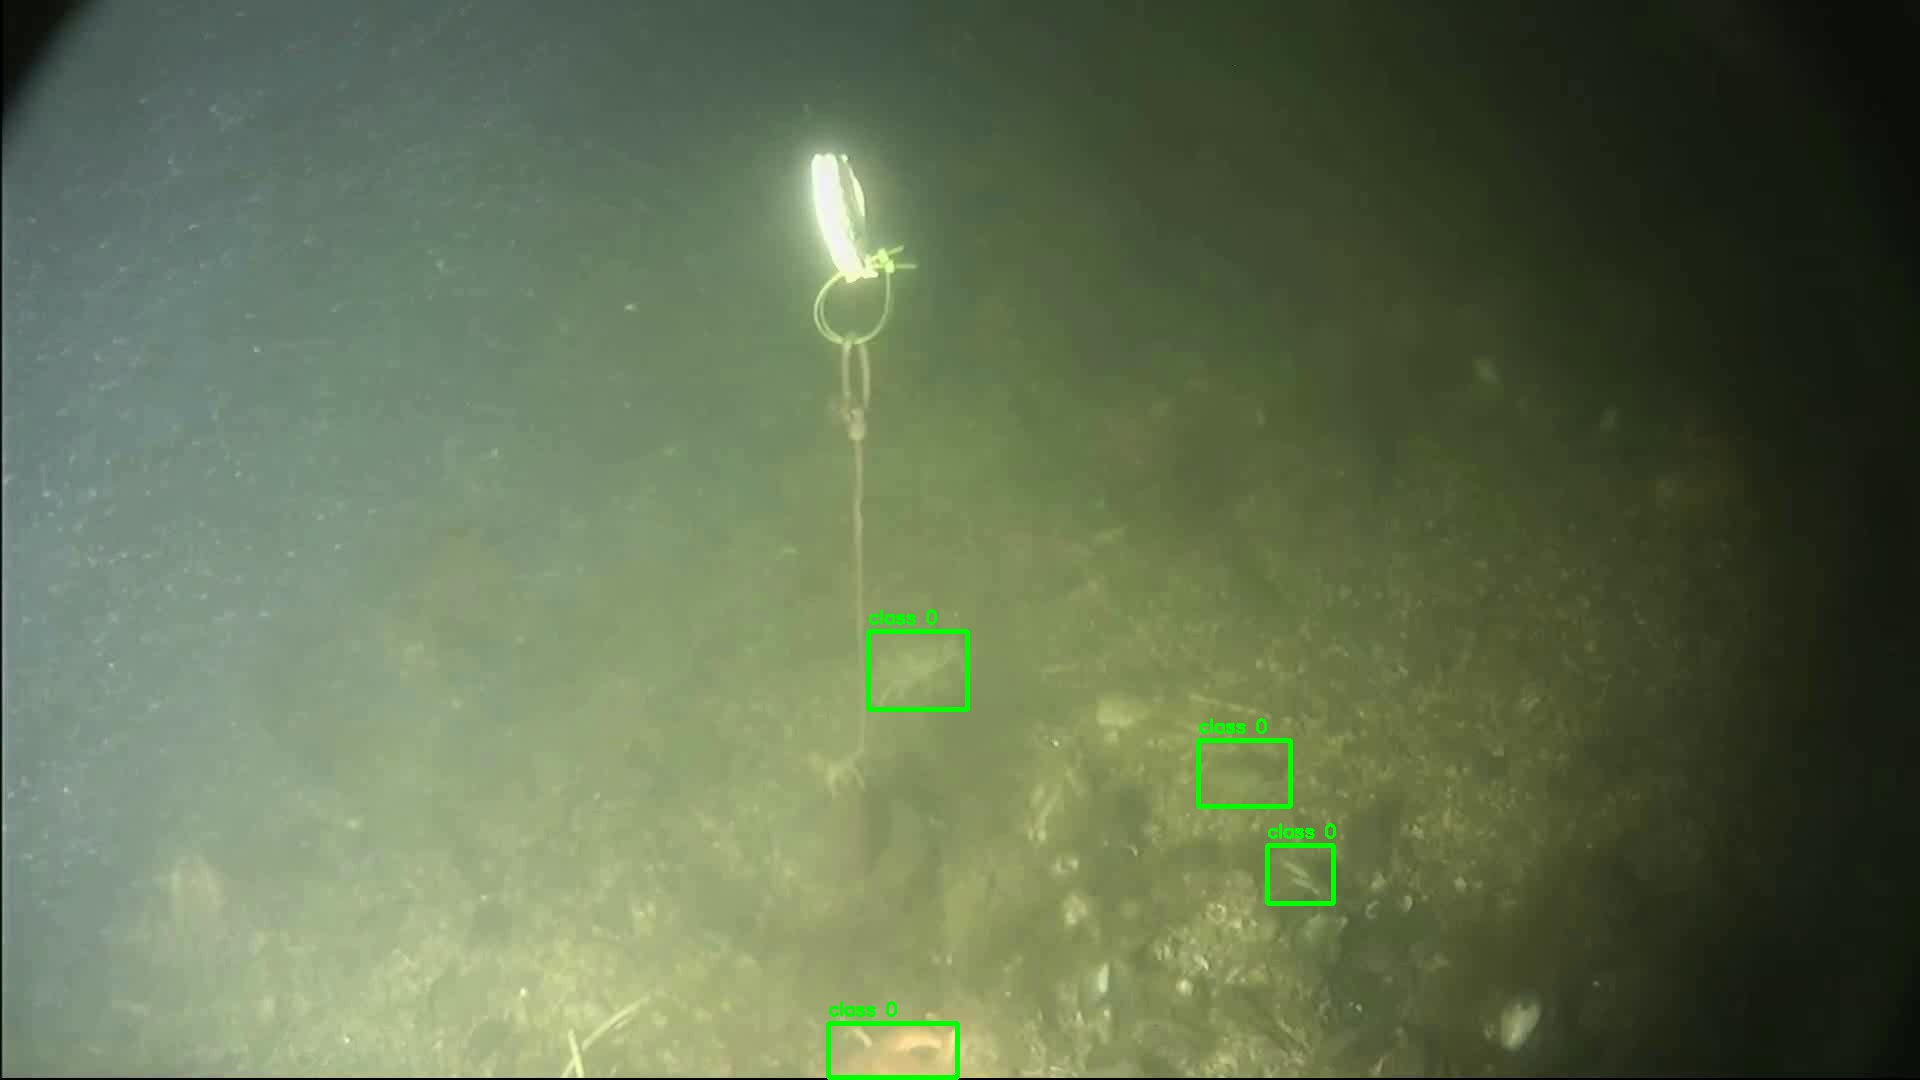

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename=(
            "/content/u-traccount/outputs/"
            "yolo_verification/converted_label_example.jpg"
        )
    )
)

## 3. YOLO11n Training and Model Selection

This section prepares persistent storage for the training outputs and fine-tunes a pretrained YOLO11n detector on the converted BrackishMOT dataset. The local output directory is linked to Google Drive so that model weights, training curves and validation results remain available if the Colab runtime disconnects.

Short smoke-test runs are performed first to confirm that the dataset configuration, batch loading, GPU execution and output paths work correctly. These preliminary runs are implementation checks and are not used as the final experimental result.

The main detector is then trained with the project configuration and validation is performed during training. Early stopping is used to reduce unnecessary computation when validation performance no longer improves. The checkpoint with the strongest validation performance, stored as `best.pt`, is selected for subsequent detection, tracking and counting experiments.

The generated training plots show the optimisation losses and validation metrics across epochs. Falling box, classification and distribution-focal losses indicate learning progress, while precision, recall and mean average precision provide measures of detector performance on unseen validation images.

In [ ]:
from pathlib import Path
import os

drive_training = Path(
    "/content/drive/MyDrive/U-TracCount/training_results"
)
local_outputs = Path("/content/u-traccount/outputs")
local_training = local_outputs / "training"

drive_training.mkdir(parents=True, exist_ok=True)
local_outputs.mkdir(parents=True, exist_ok=True)

if local_training.is_symlink():
    print("Training link already exists.")
elif local_training.exists():
    print("A regular training folder already exists:", local_training)
else:
    os.symlink(
        drive_training,
        local_training,
        target_is_directory=True,
    )
    print("Training link created.")

print("Local path:", local_training)
print("Saves into:", local_training.resolve())

Training link created.
Local path: /content/u-traccount/outputs/training
Saves into: /content/drive/MyDrive/U-TracCount/training_results


In [ ]:
%cd /content/u-traccount
!python src/train_detector.py --epochs 1 --batch 16 --fraction 0.01 --device 0 --name colab_gpu_smoke_test

In [ ]:
%cd /content/u-traccount
!python src/train_detector.py --epochs 1 --batch 32 --fraction 0.01 --device 0 --name colab_batch32_test

In [ ]:
%cd /content/u-traccount
!python src/train_detector.py --epochs 30 --batch 32 --fraction 1.0 --device 0 --name brackishmot_yolo11n_30epochs

/content/u-traccount
Dataset configuration: /content/u-traccount/configs/brackishmot.yaml
Epochs: 30
Batch size: 32
Device: 0
Dataset fraction: 1.0
New https://pypi.org/project/ultralytics/8.4.130 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.123 🚀 Python-3.13.15 torch-2.13.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/u-traccount/configs/brackishmot.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None,

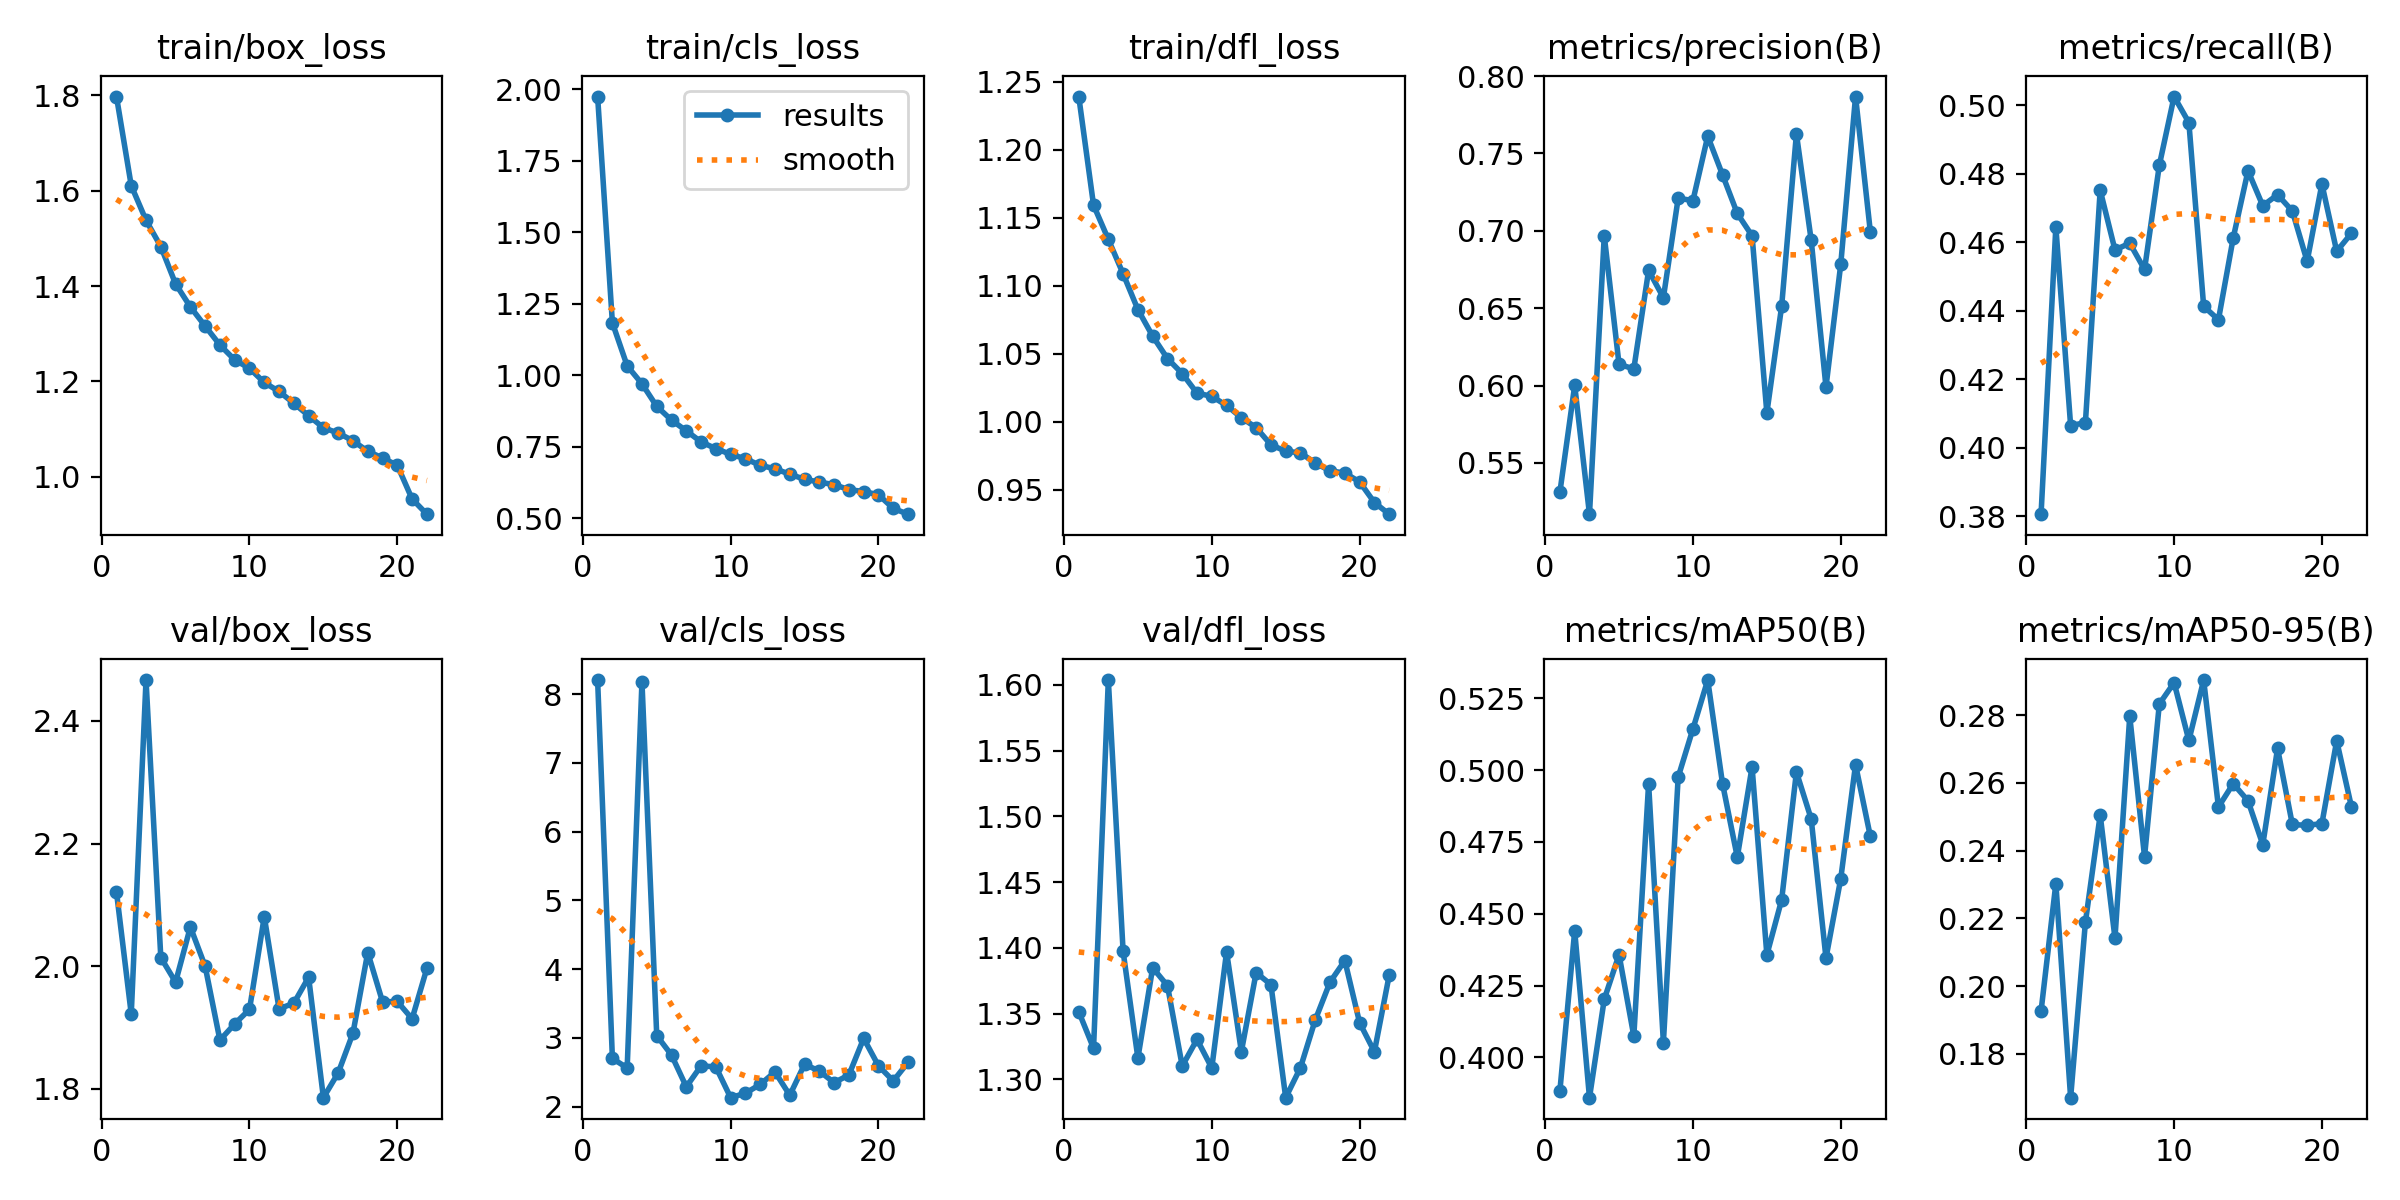

In [ ]:
from IPython.display import display, Image

results_image = (
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "brackishmot_yolo11n_30epochs/results.png"
)

display(Image(filename=results_image))

## 4. Held-Out Detection Evaluation

The selected `best.pt` checkpoint is evaluated on BrackishMOT sequences that were excluded from detector training. A preliminary single-image prediction is displayed first to confirm that the saved model loads correctly and produces plausible underwater-creature detections.

Predicted bounding boxes are then compared visually with the corresponding ground-truth MOT annotations. These overlays provide a qualitative check of localisation, missed detections and false detections before the complete test partition is evaluated.

The held-out MOTChallenge annotations are converted into a separate YOLO test configuration and evaluated using the Ultralytics validation procedure. The principal reported detection measures are:

- **Precision:** the proportion of predicted detections that correspond to annotated objects.
- **Recall:** the proportion of annotated objects successfully detected.
- **mAP@0.5:** mean average precision at an intersection-over-union threshold of 0.5.
- **mAP@0.5–0.95:** mean average precision averaged across stricter intersection-over-union thresholds.
- **Inference speed:** the processing time required per image, reported by the evaluation routine.

The confidence and precision–recall curves generated below are retained as supporting diagnostic outputs. These held-out results, rather than the training-set performance, form the detector evaluation reported in the dissertation.


image 1/1 /content/u-traccount/data/raw/BrackishMOT/BrackishMOT/test/brackishMOT-03/img1/000001.jpg: 384x640 1 underwater_creature, 8.4ms
Speed: 24.3ms preprocess, 8.4ms inference, 12.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/drive/MyDrive/U-TracCount/training_results/qualitative_test
Test image: /content/u-traccount/data/raw/BrackishMOT/BrackishMOT/test/brackishMOT-03/img1/000001.jpg
Prediction: /content/drive/MyDrive/U-TracCount/training_results/qualitative_test/000001.jpg


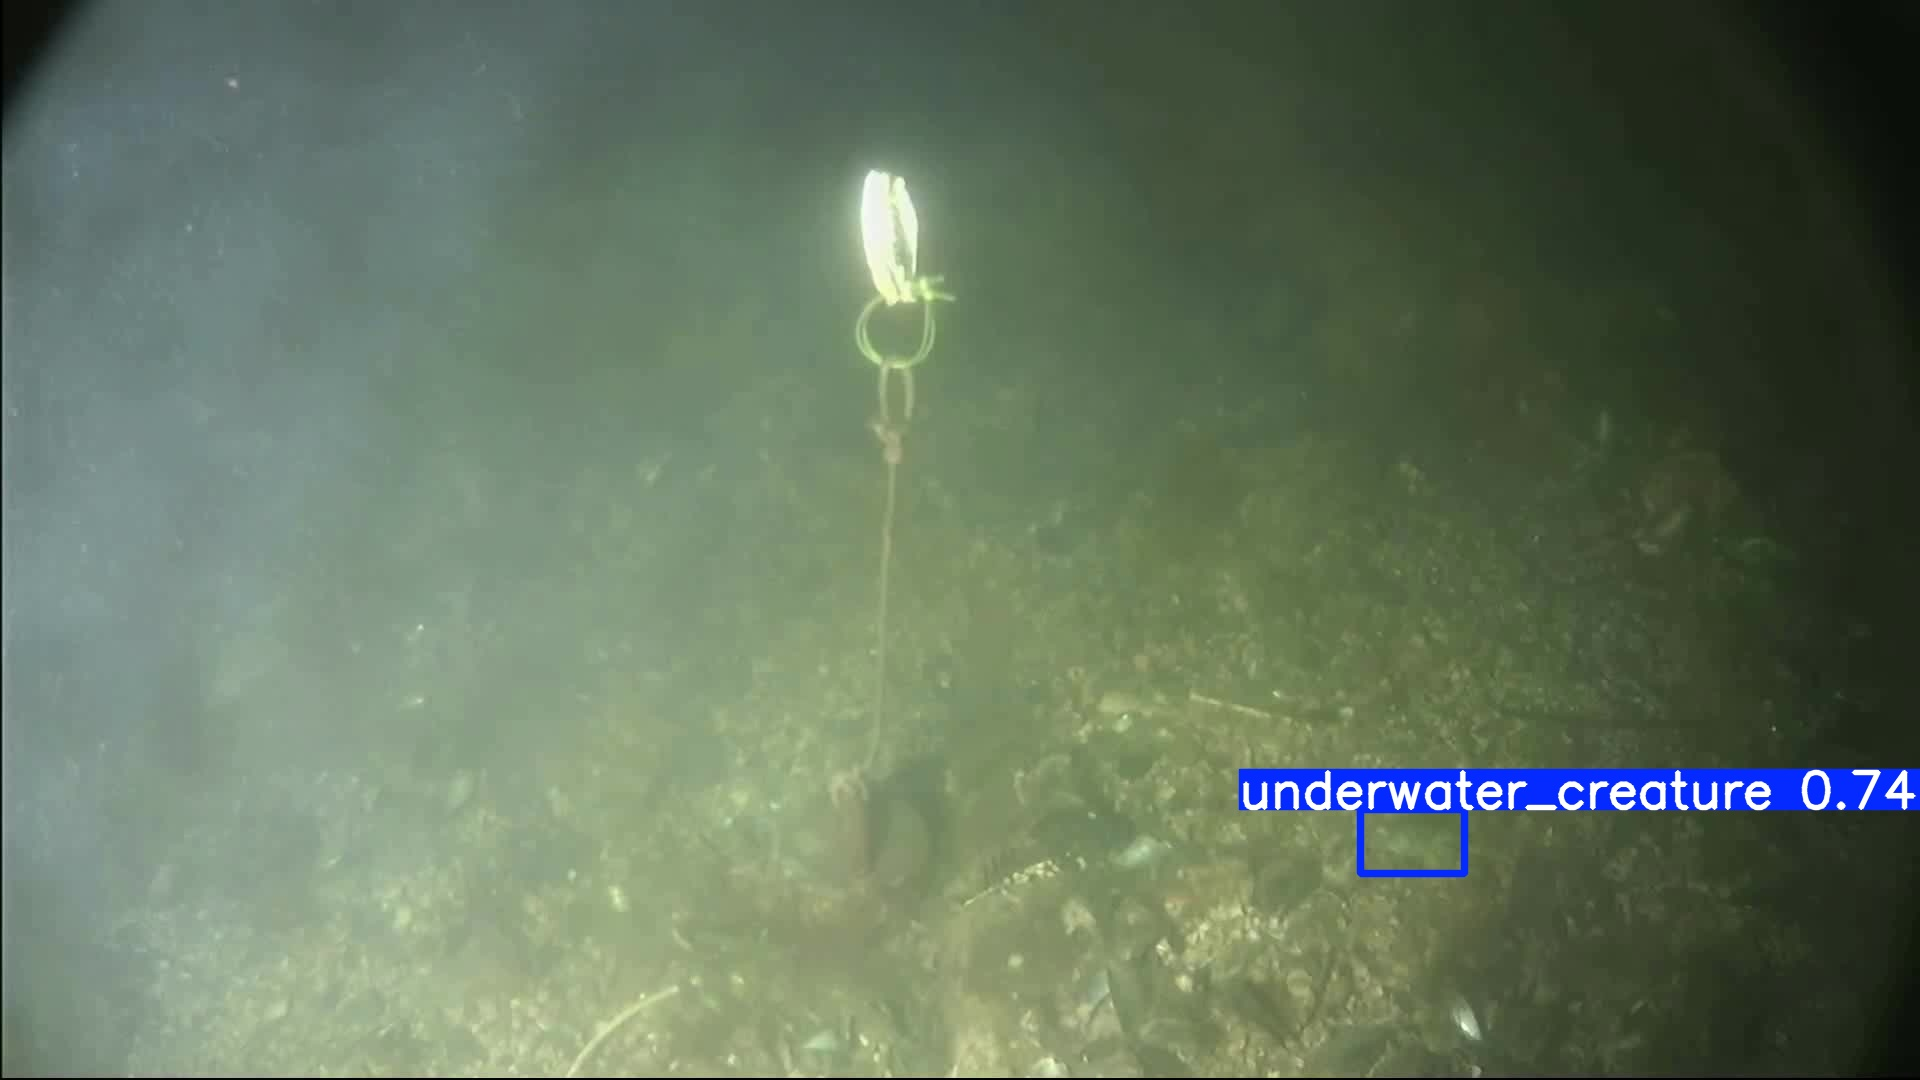

In [ ]:
from pathlib import Path
from ultralytics import YOLO
from IPython.display import display, Image

test_root = Path(
    "/content/u-traccount/data/raw/BrackishMOT/"
    "BrackishMOT/test"
)

test_images = sorted(test_root.glob("*/img1/*.jpg"))
test_image = test_images[0]

best_model = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "brackishmot_yolo11n_30epochs/weights/best.pt"
)

prediction_directory = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "qualitative_test"
)

model = YOLO(str(best_model))

model.predict(
    source=str(test_image),
    conf=0.25,
    save=True,
    project=str(prediction_directory.parent),
    name=prediction_directory.name,
    exist_ok=True,
)

output_image = prediction_directory / test_image.name

print("Test image:", test_image)
print("Prediction:", output_image)
display(Image(filename=str(output_image)))

Ground-truth creatures: 4


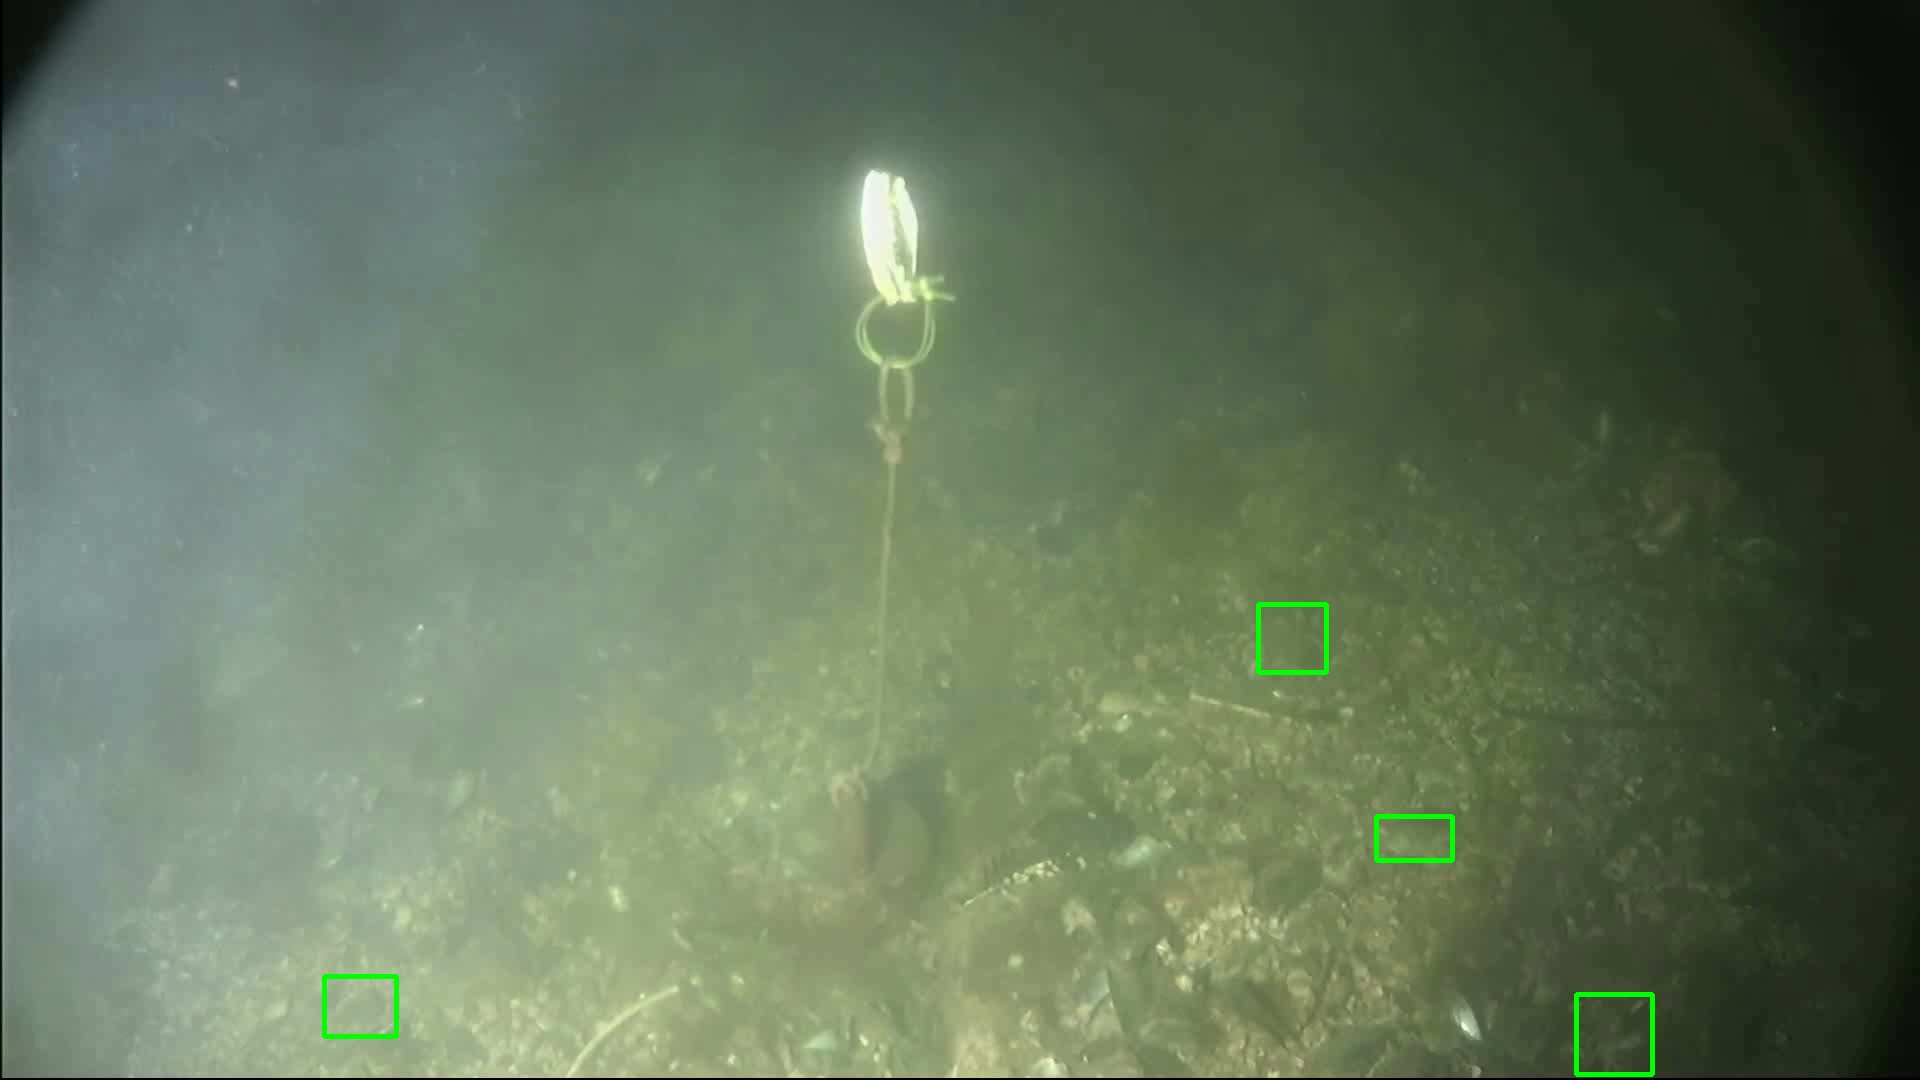

In [ ]:
import csv
from pathlib import Path

import cv2
from IPython.display import display, Image

test_image = Path(
    "/content/u-traccount/data/raw/BrackishMOT/"
    "BrackishMOT/test/brackishMOT-03/img1/000001.jpg"
)

ground_truth_file = (
    test_image.parents[1] / "gt" / "gt.txt"
)

frame_number = int(test_image.stem)
image = cv2.imread(str(test_image))
ground_truth_count = 0

with ground_truth_file.open("r", newline="") as file:
    for row in csv.reader(file):
        if len(row) < 6:
            continue

        if int(float(row[0])) != frame_number:
            continue

        if len(row) >= 7 and float(row[6]) <= 0:
            continue

        x = int(float(row[2]))
        y = int(float(row[3]))
        width = int(float(row[4]))
        height = int(float(row[5]))

        cv2.rectangle(
            image,
            (x, y),
            (x + width, y + height),
            (0, 255, 0),
            3,
        )

        ground_truth_count += 1

output_file = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "qualitative_test/000001_ground_truth.jpg"
)

cv2.imwrite(str(output_file), image)

print("Ground-truth creatures:", ground_truth_count)
display(Image(filename=str(output_file)))

Ground truth: 4
Predictions: 1
Best IoUs: [0.502]
True positives: 1
False positives: 0
False negatives: 3
Green = ground truth; Blue = prediction


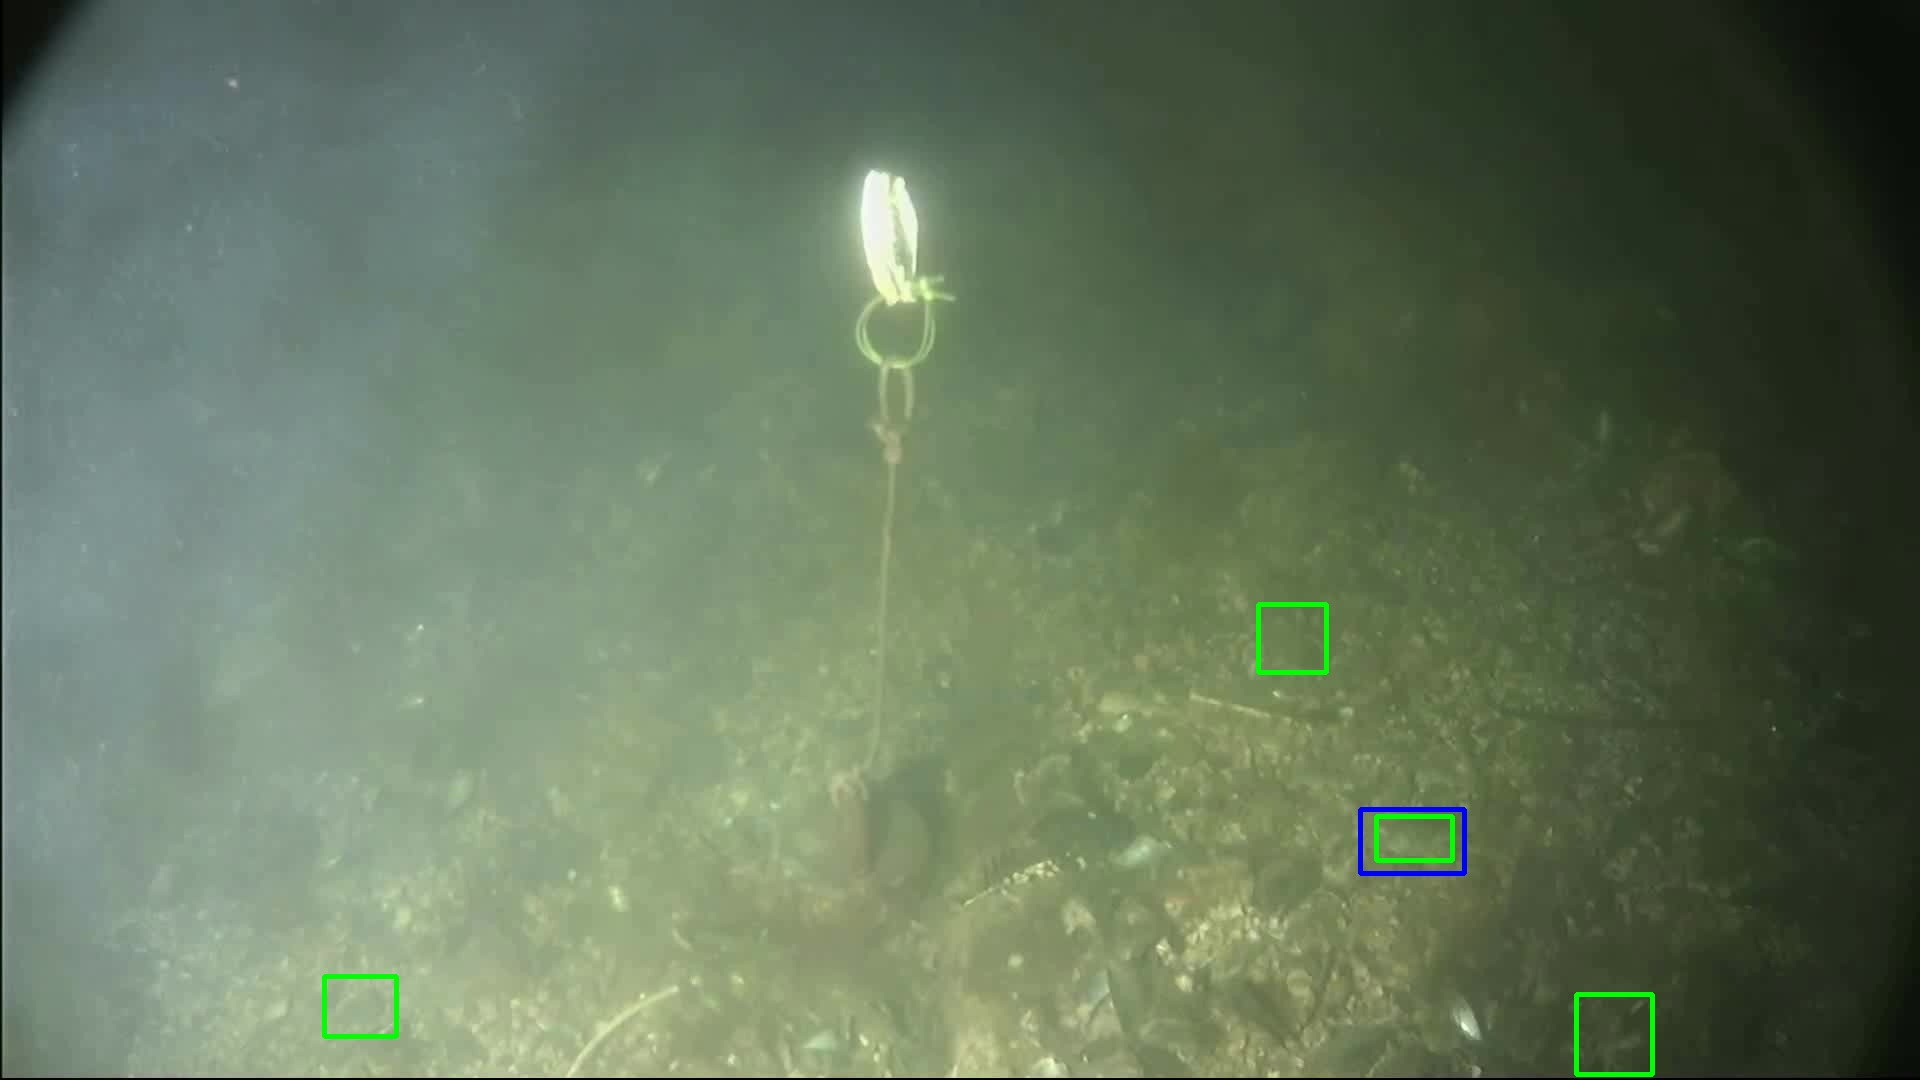

In [ ]:
import csv
from pathlib import Path

import cv2
from ultralytics import YOLO
from IPython.display import display, Image

test_image = Path(
    "/content/u-traccount/data/raw/BrackishMOT/"
    "BrackishMOT/test/brackishMOT-03/img1/000001.jpg"
)

ground_truth_file = test_image.parents[1] / "gt" / "gt.txt"

best_model = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "brackishmot_yolo11n_30epochs/weights/best.pt"
)

model = YOLO(str(best_model))
result = model.predict(
    source=str(test_image),
    conf=0.25,
    verbose=False,
)[0]

predicted_boxes = result.boxes.xyxy.cpu().tolist()
ground_truth_boxes = []
frame_number = int(test_image.stem)

with ground_truth_file.open("r", newline="") as file:
    for row in csv.reader(file):
        if len(row) < 6 or int(float(row[0])) != frame_number:
            continue
        if len(row) >= 7 and float(row[6]) <= 0:
            continue

        x, y, width, height = map(float, row[2:6])
        ground_truth_boxes.append(
            [x, y, x + width, y + height]
        )


def calculate_iou(box_a, box_b):
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    return intersection / (area_a + area_b - intersection + 1e-9)


best_ious = [
    max(
        (calculate_iou(prediction, truth)
         for truth in ground_truth_boxes),
        default=0,
    )
    for prediction in predicted_boxes
]

true_positives = sum(iou >= 0.5 for iou in best_ious)
false_positives = len(predicted_boxes) - true_positives
false_negatives = len(ground_truth_boxes) - true_positives

image = cv2.imread(str(test_image))

for box in ground_truth_boxes:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 3)

for box in predicted_boxes:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 3)

output_file = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "qualitative_test/000001_comparison.jpg"
)

cv2.imwrite(str(output_file), image)

print("Ground truth:", len(ground_truth_boxes))
print("Predictions:", len(predicted_boxes))
print("Best IoUs:", [round(value, 3) for value in best_ious])
print("True positives:", true_positives)
print("False positives:", false_positives)
print("False negatives:", false_negatives)
print("Green = ground truth; Blue = prediction")

display(Image(filename=str(output_file)))

In [ ]:
from pathlib import Path
import src.convert_mot_to_yolo as converter

project_root = Path("/content/u-traccount")

test_source = (
    project_root
    / "data/raw/BrackishMOT/BrackishMOT/test"
)

test_output = (
    project_root
    / "data/processed/brackishmot_yolo_test"
)

test_config = (
    project_root
    / "configs/brackishmot_test.yaml"
)

converter.OUTPUT_ROOT = test_output

sequences = sorted(
    directory
    for directory in test_source.iterdir()
    if directory.is_dir()
)

total_images = 0
total_boxes = 0

for sequence in sequences:
    image_count, box_count = converter.convert_sequence(
        sequence,
        "val",
    )

    total_images += image_count
    total_boxes += box_count

    print(
        f"Converted {sequence.name}: "
        f"{image_count} images, {box_count} boxes"
    )

test_config.write_text(
    f"path: {test_output.as_posix()}\n"
    "train: images/val\n"
    "val: images/val\n\n"
    "names:\n"
    "  0: underwater_creature\n",
    encoding="utf-8",
)

print("\nTest conversion complete")
print("Test sequences:", len(sequences))
print("Test images:", total_images)
print("Test boxes:", total_boxes)
print("Test configuration:", test_config)

Converted brackishMOT-03: 130 images, 520 boxes
Converted brackishMOT-10: 131 images, 262 boxes
Converted brackishMOT-14: 183 images, 345 boxes
Converted brackishMOT-17: 139 images, 608 boxes
Converted brackishMOT-23: 121 images, 453 boxes
Converted brackishMOT-26: 126 images, 421 boxes
Converted brackishMOT-33: 190 images, 979 boxes
Converted brackishMOT-34: 149 images, 559 boxes
Converted brackishMOT-36: 200 images, 156 boxes
Converted brackishMOT-50: 301 images, 2129 boxes
Converted brackishMOT-55: 256 images, 3192 boxes
Converted brackishMOT-56: 171 images, 87 boxes
Converted brackishMOT-67: 181 images, 636 boxes
Converted brackishMOT-74: 111 images, 124 boxes
Converted brackishMOT-83: 113 images, 41 boxes
Converted brackishMOT-88: 111 images, 87 boxes
Converted brackishMOT-90: 313 images, 426 boxes
Converted brackishMOT-93: 150 images, 1567 boxes
Converted brackishMOT-95: 181 images, 148 boxes
Converted brackishMOT-98: 230 images, 1930 boxes

Test conversion complete
Test sequence

In [ ]:
from pathlib import Path
from ultralytics import YOLO

best_model = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "brackishmot_yolo11n_30epochs/weights/best.pt"
)

test_config = Path(
    "/content/u-traccount/configs/brackishmot_test.yaml"
)

evaluation_directory = Path(
    "/content/drive/MyDrive/U-TracCount/training_results"
)

model = YOLO(str(best_model))

metrics = model.val(
    data=str(test_config),
    split="val",
    imgsz=640,
    batch=32,
    device=0,
    workers=0,
    project=str(evaluation_directory),
    name="held_out_test_evaluation",
    exist_ok=True,
    plots=True,
)

print("\nHeld-out test results")
print("Precision:", round(metrics.box.mp, 4))
print("Recall:", round(metrics.box.mr, 4))
print("mAP50:", round(metrics.box.map50, 4))
print("mAP50-95:", round(metrics.box.map, 4))
print("Speed:", metrics.speed)

Ultralytics 8.4.123 🚀 Python-3.13.15 torch-2.13.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 24.5±7.3 MB/s, size: 57.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/u-traccount/data/processed/brackishmot_yolo_test/labels/val... 3487 images, 469 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3487/3487 722.3it/s 4.8s
val: New cache created: /content/u-traccount/data/processed/brackishmot_yolo_test/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 109/109 2.0it/s 55.8s
                   all       3487      14670      0.769      0.512      0.551       0.29
Speed: 0.2ms preprocess, 2.2ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/d

Curve files found:
BoxF1_curve.png


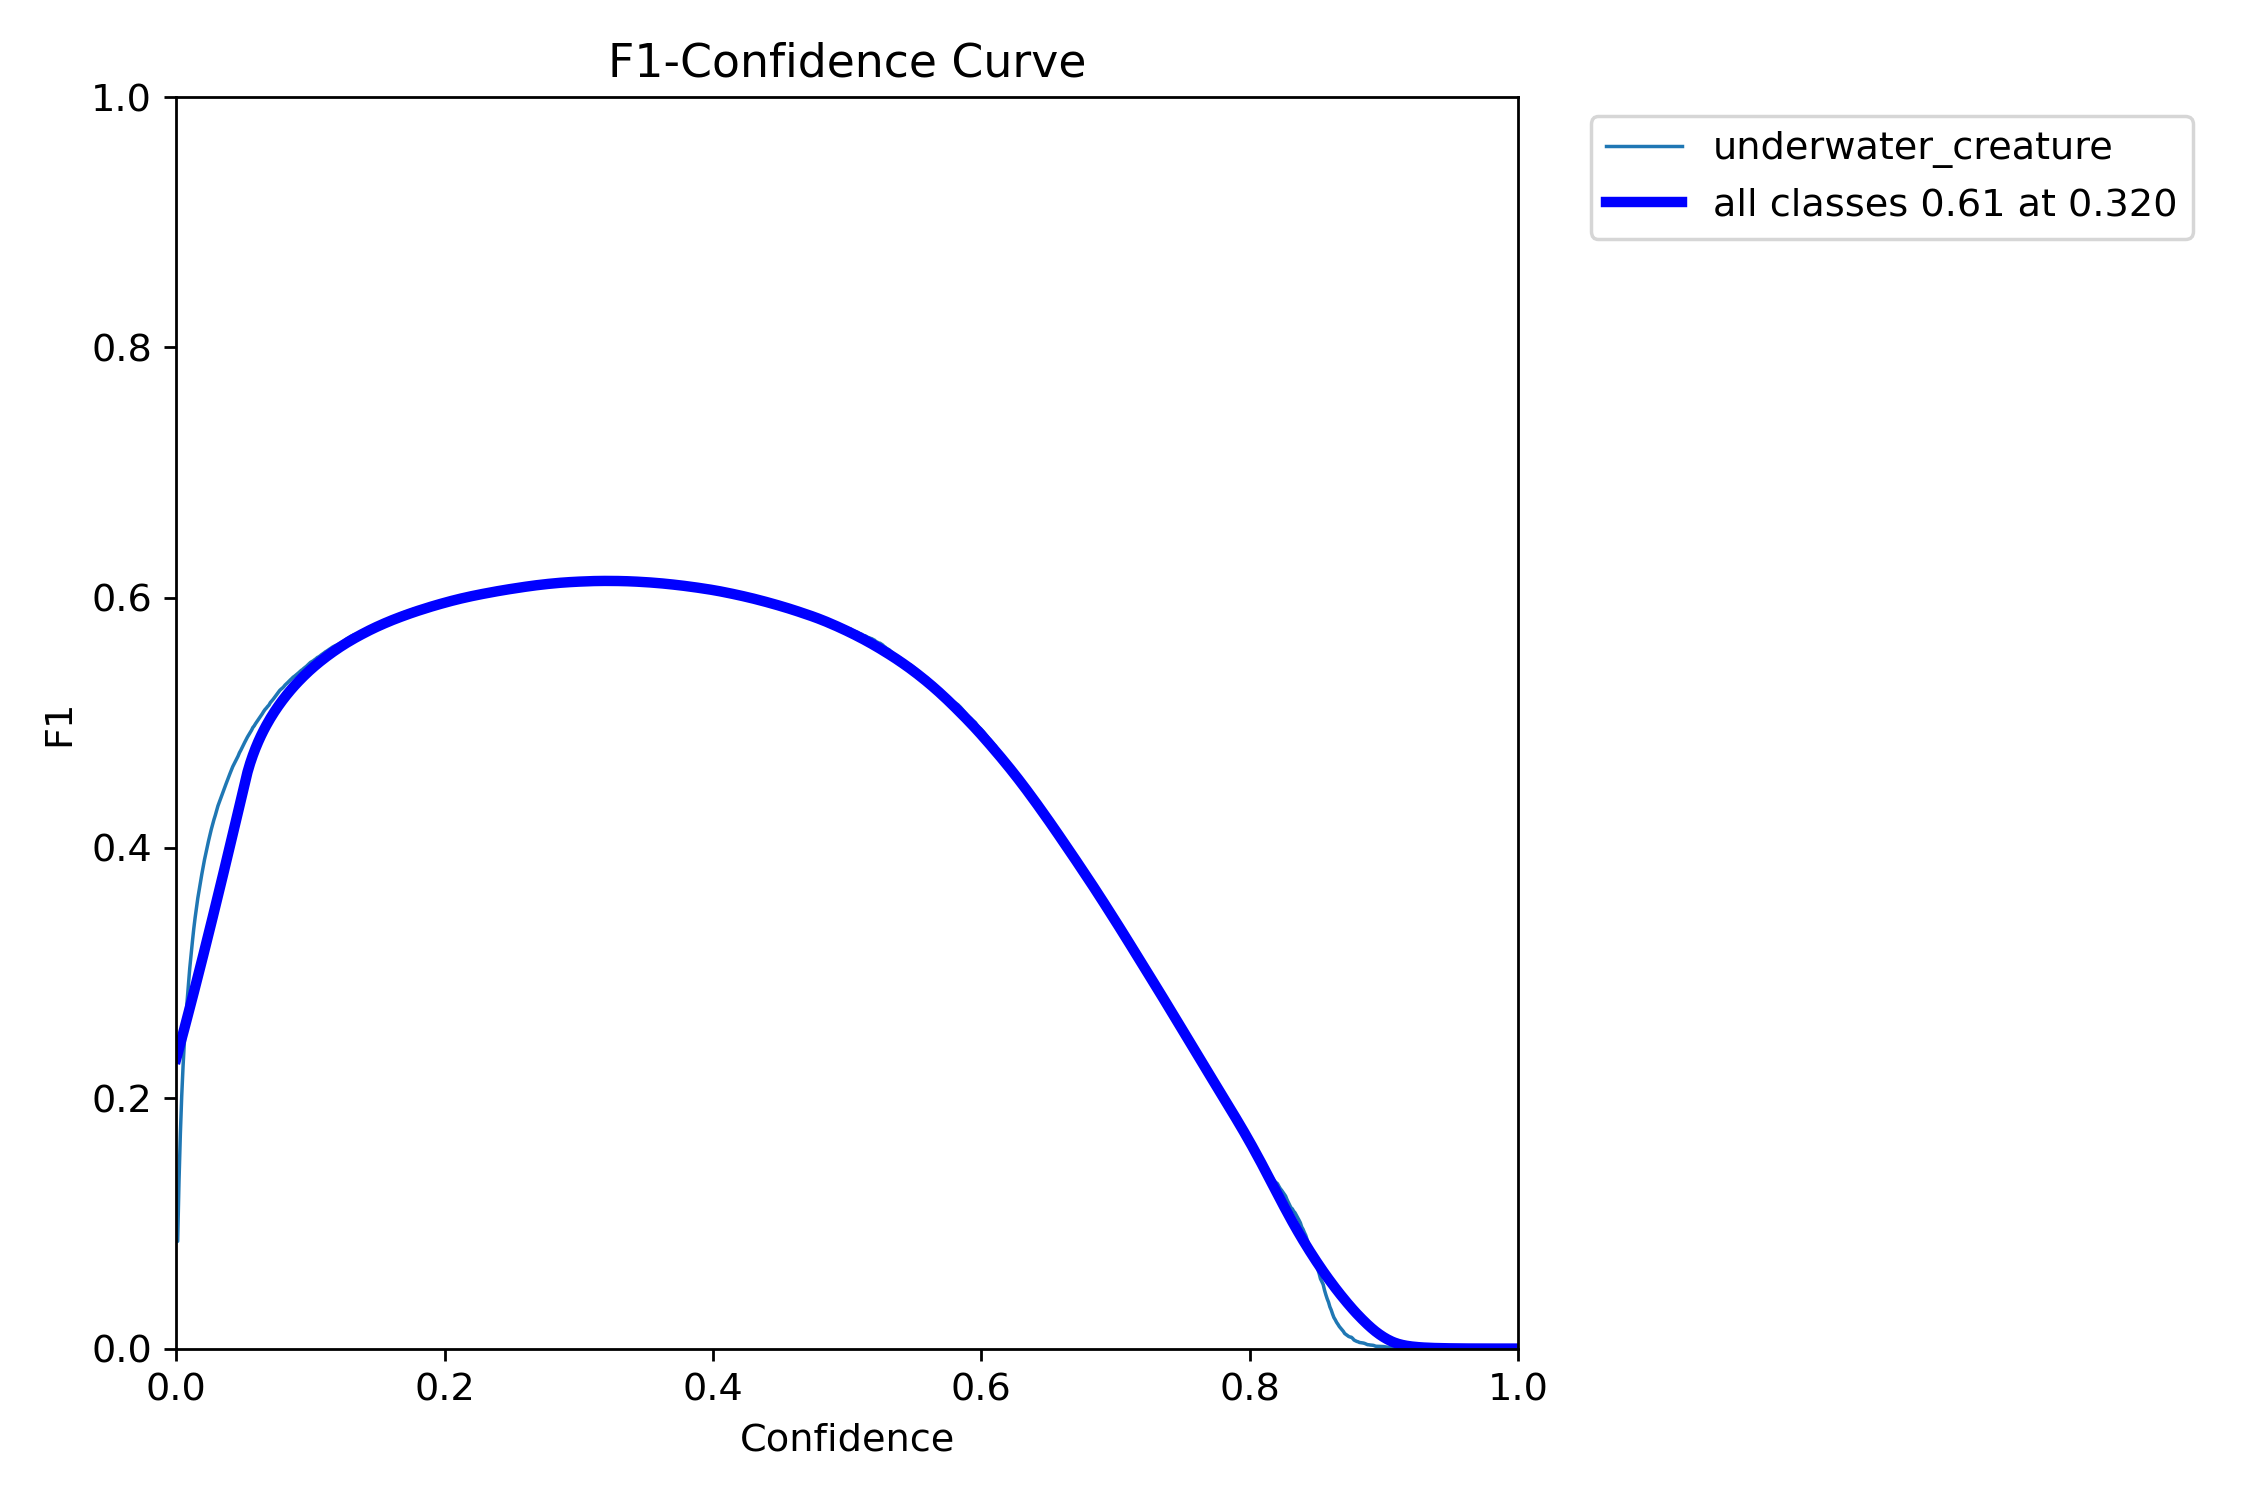

BoxPR_curve.png


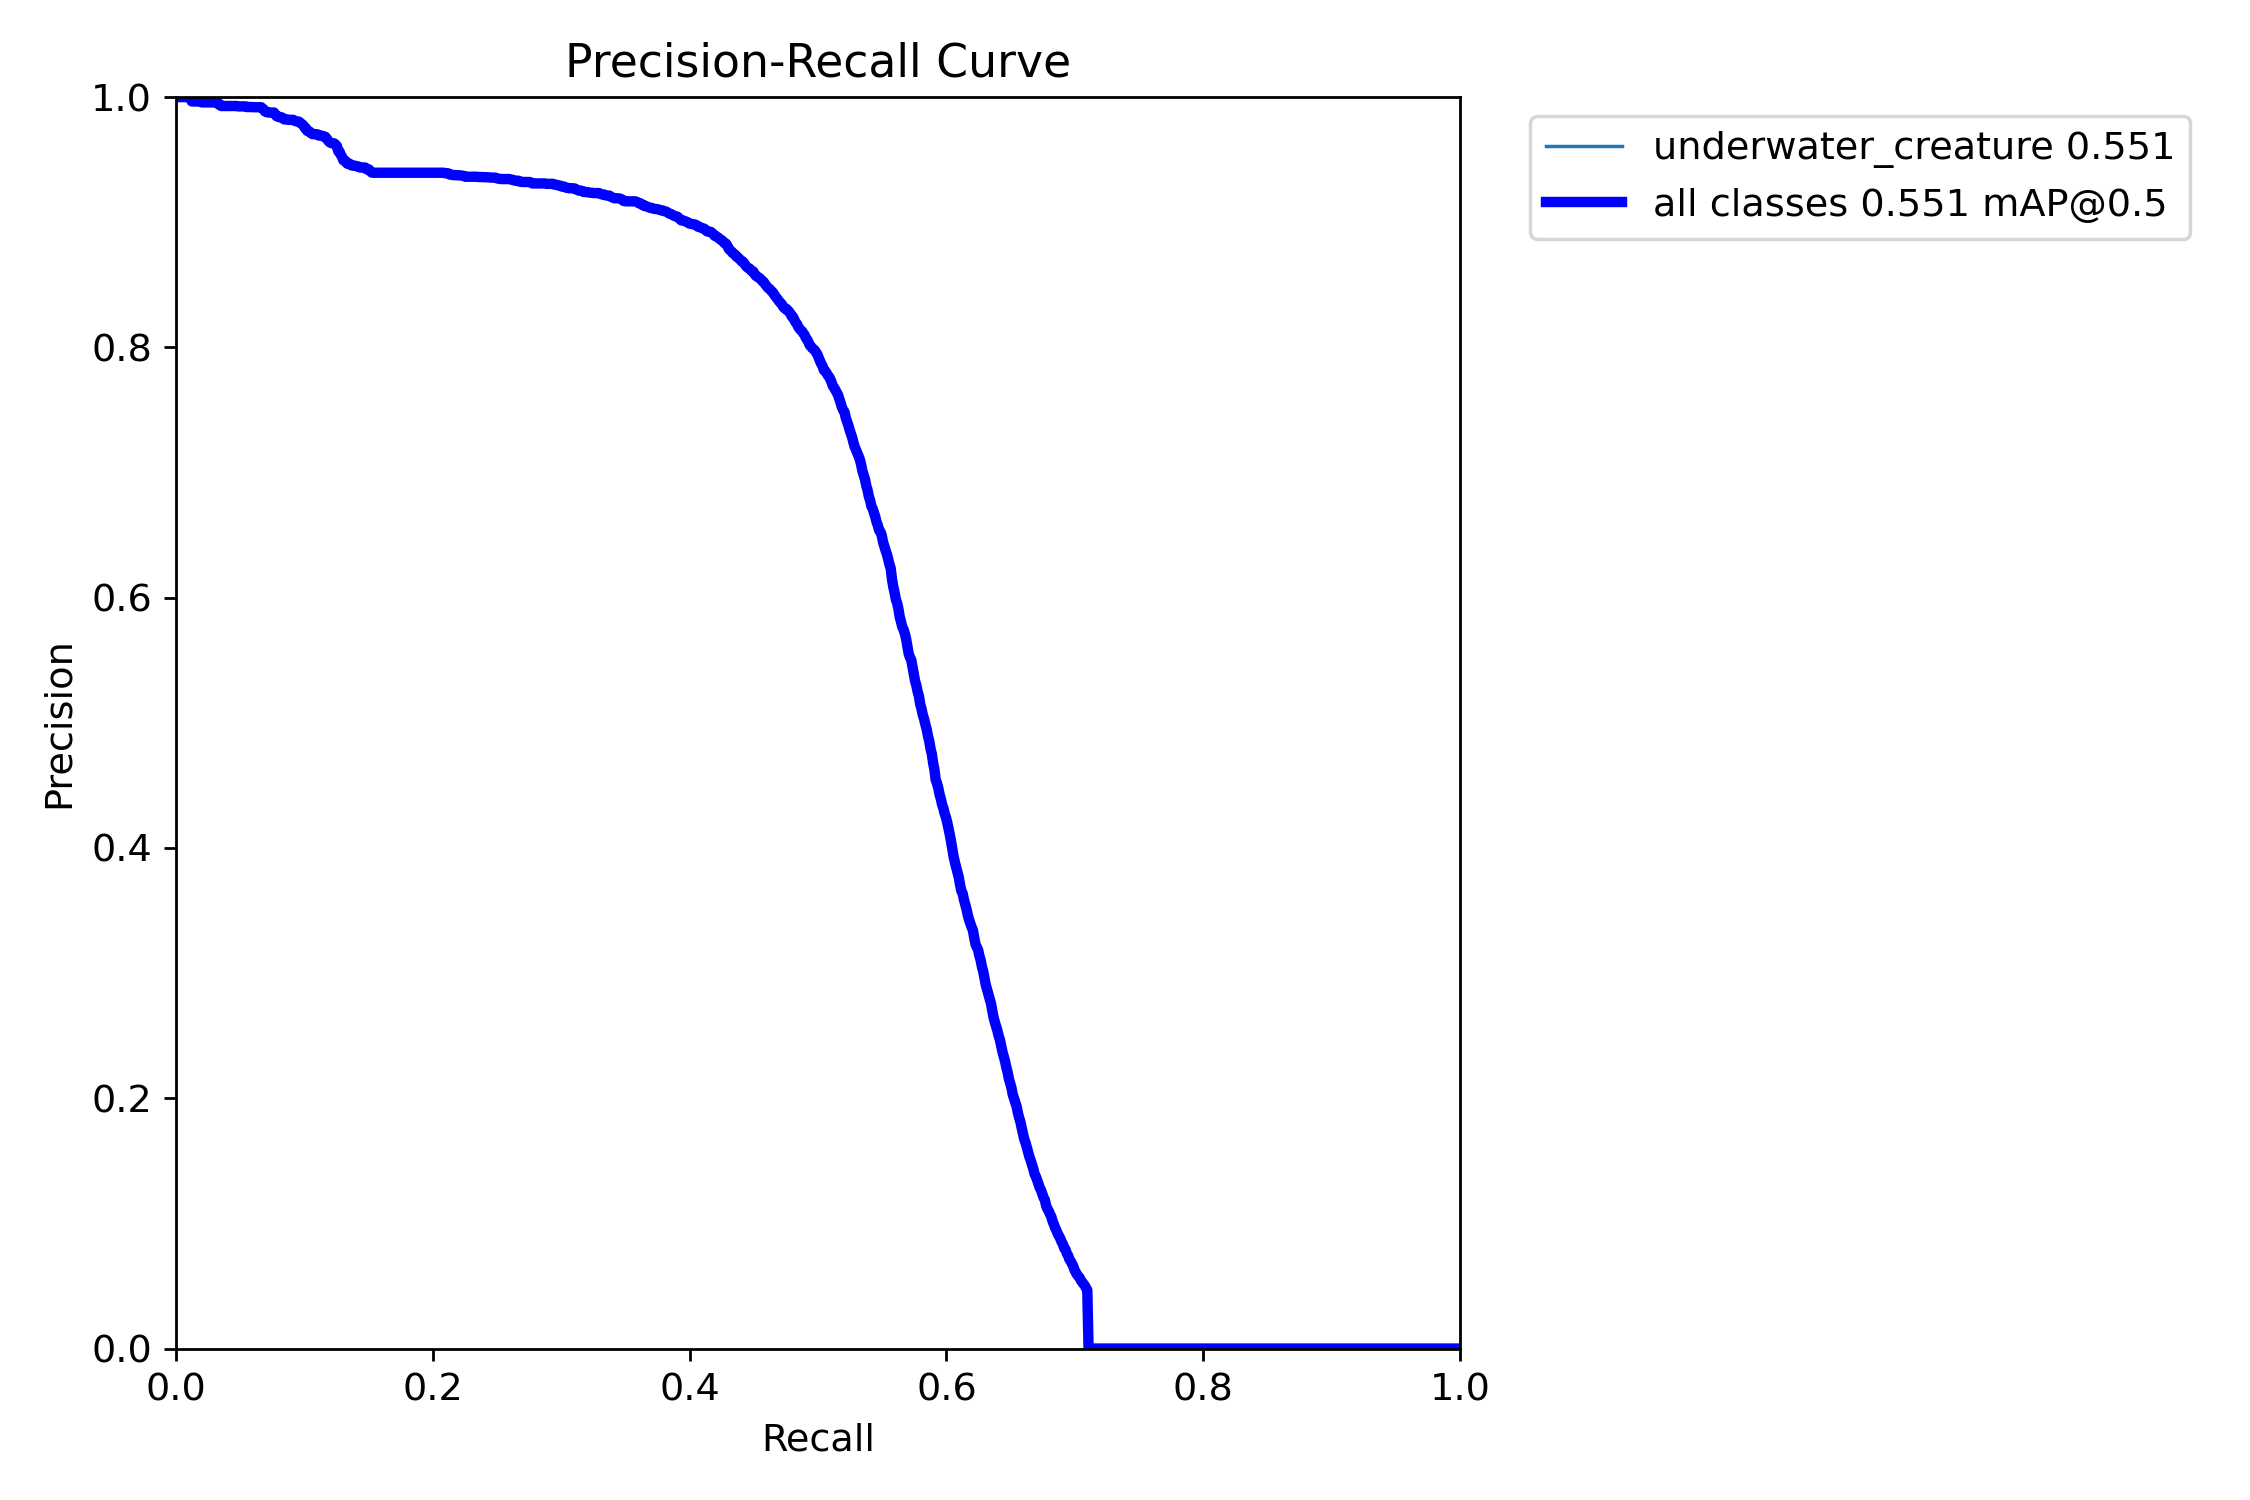

BoxP_curve.png


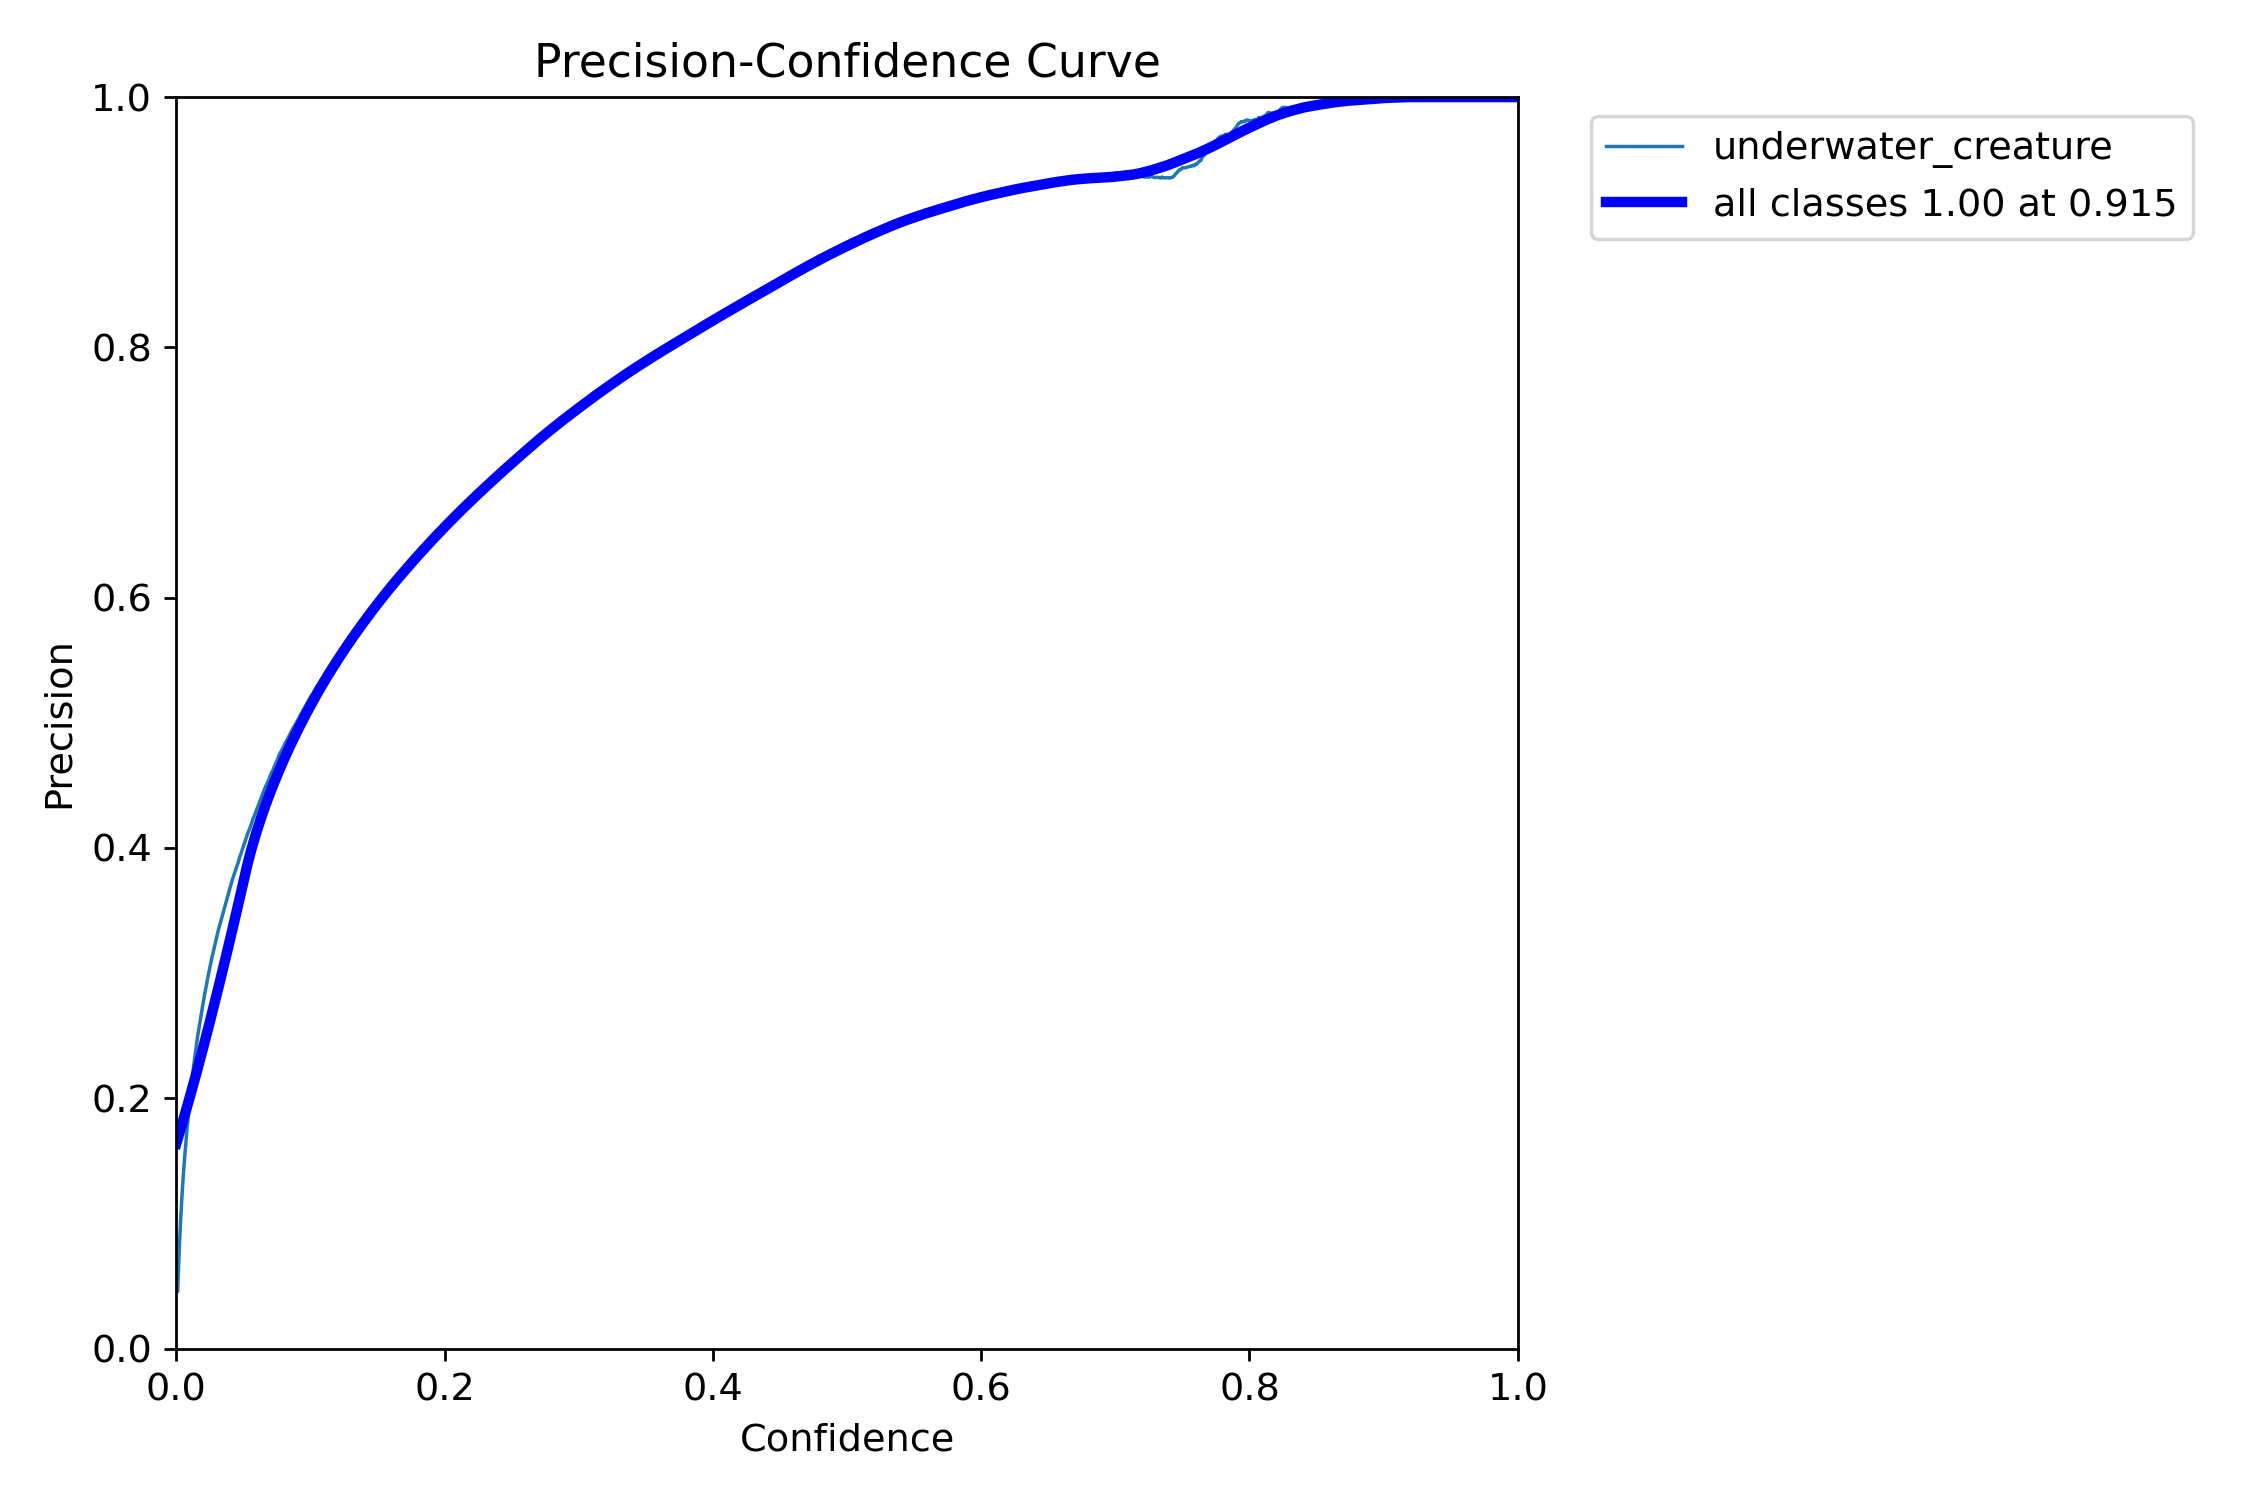

BoxR_curve.png


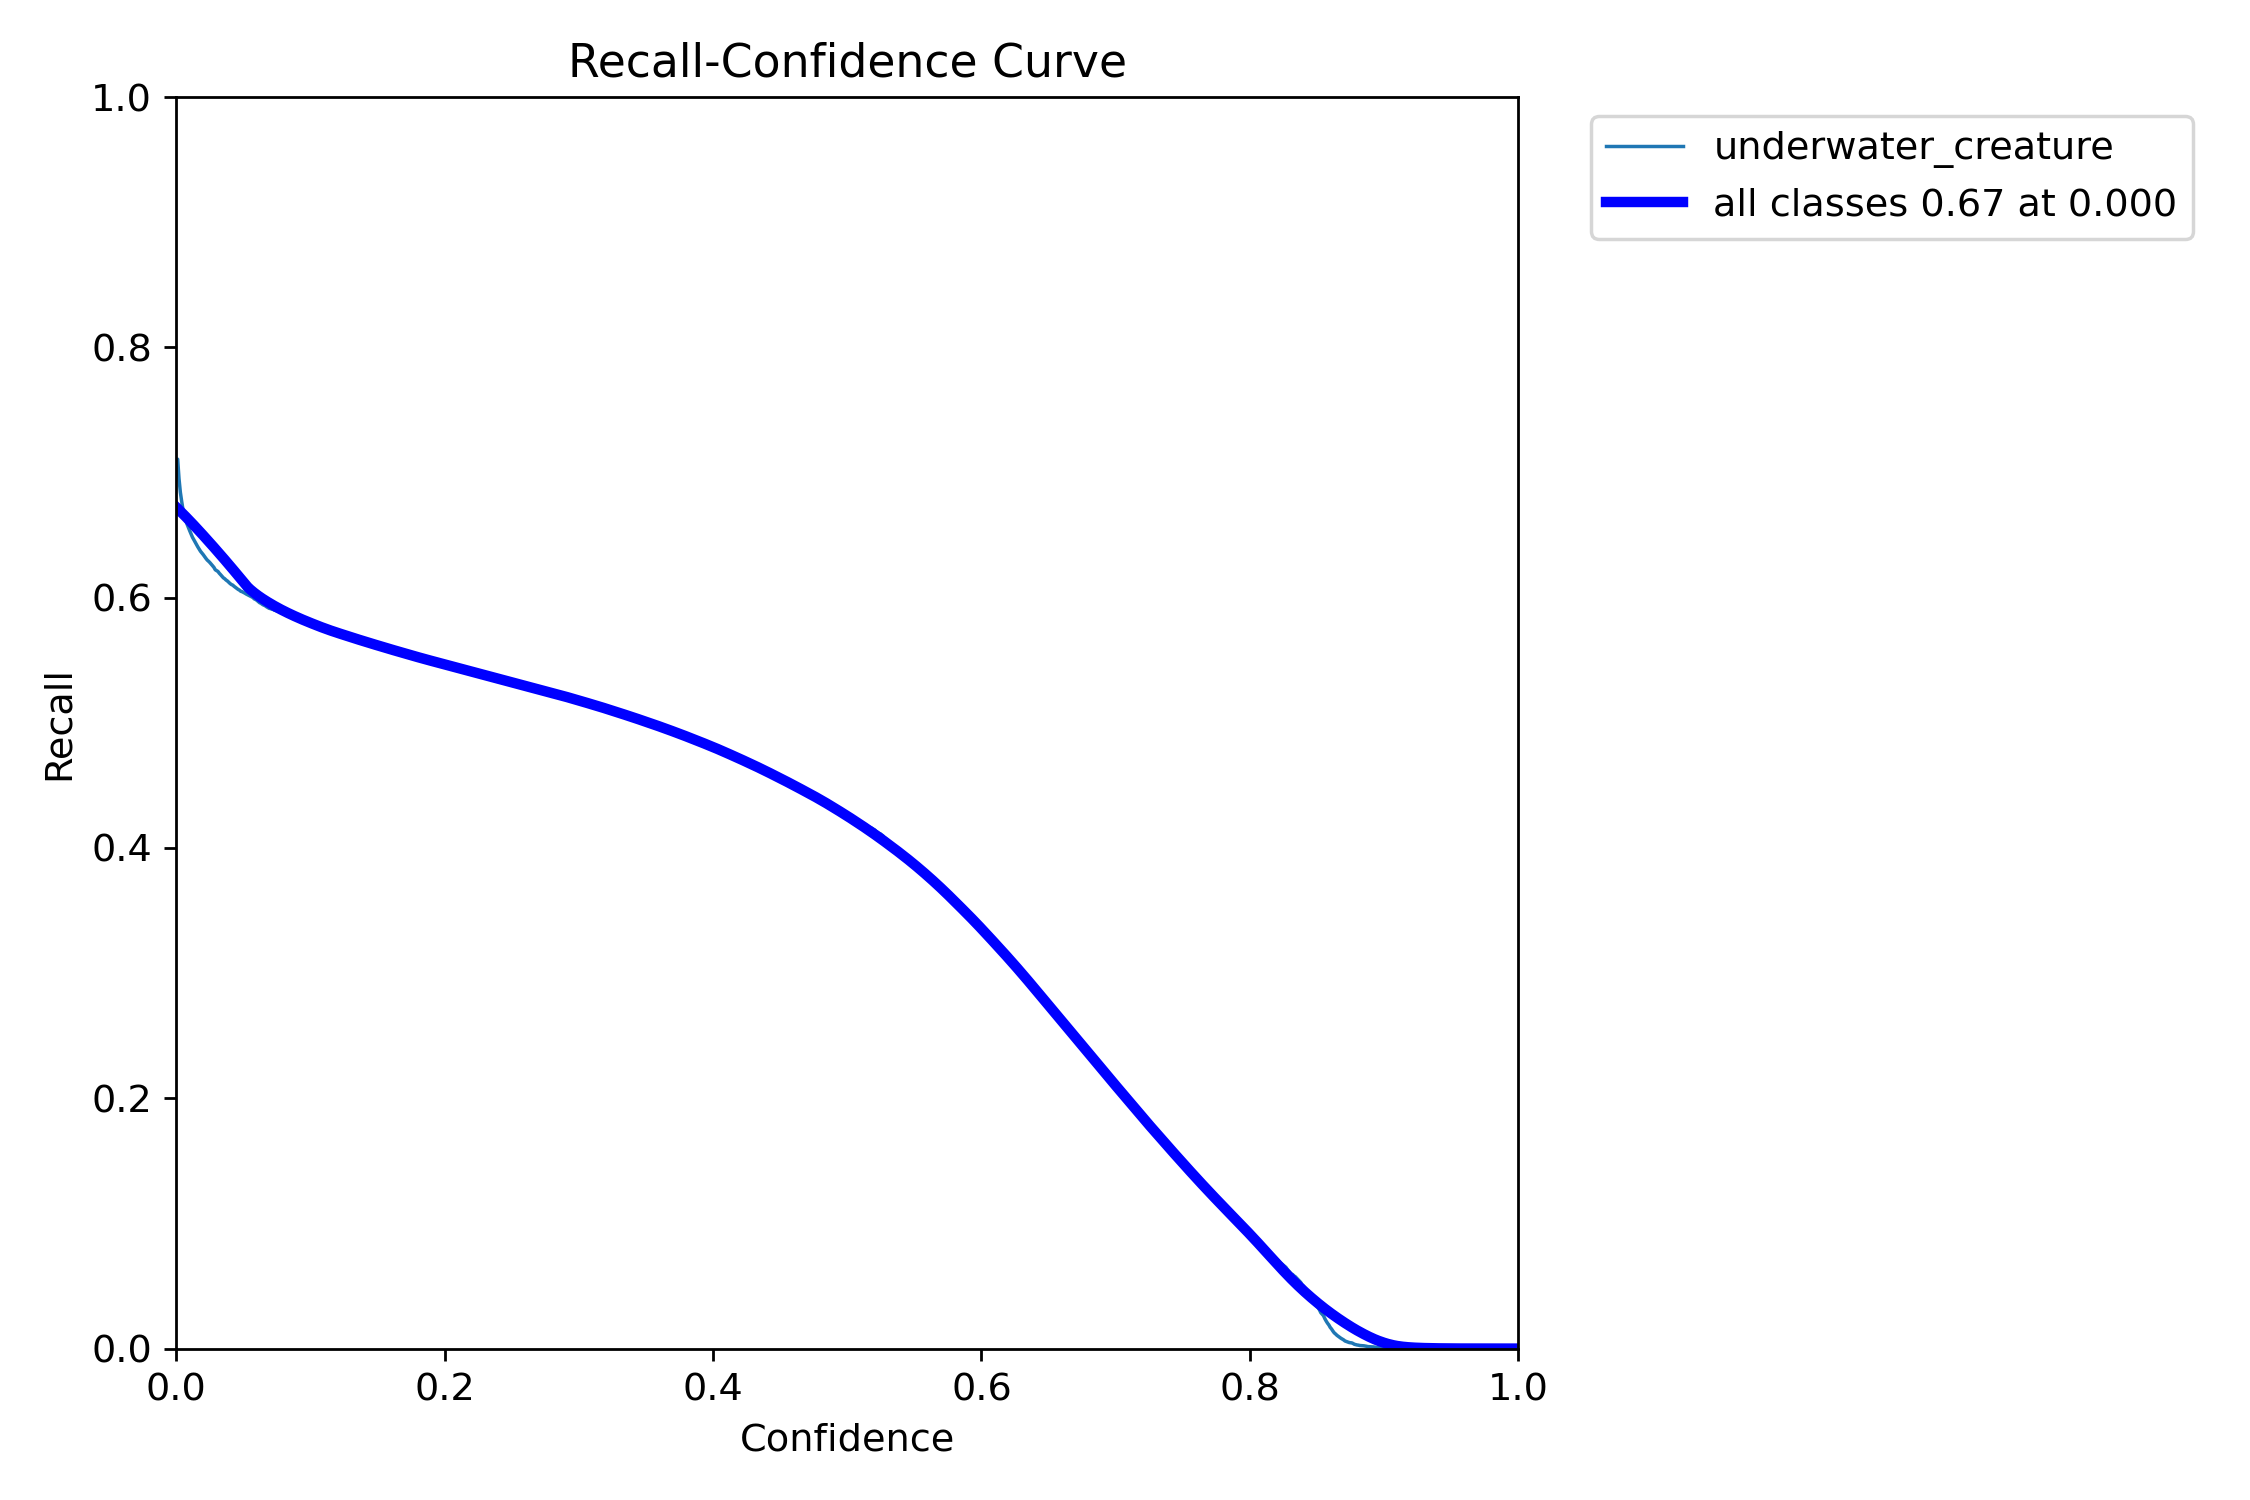

In [ ]:
from pathlib import Path
from IPython.display import display, Image

evaluation_path = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "held_out_test_evaluation"
)

curve_files = sorted(
    evaluation_path.glob("*curve*.png")
)

print("Curve files found:")

for curve_file in curve_files:
    print(curve_file.name)
    display(Image(filename=str(curve_file)))

In [ ]:
from pathlib import Path
from google.colab import files

evaluation_path = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "held_out_test_evaluation"
)

curve_names = [
    "BoxPR_curve.png",
    "BoxF1_curve.png",
]

for curve_name in curve_names:
    curve_file = evaluation_path / curve_name

    if curve_file.exists():
        print("Downloading:", curve_file.name)
        files.download(str(curve_file))
    else:
        print("Not found:", curve_file)

Downloading: BoxPR_curve.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: BoxF1_curve.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from pathlib import Path
from google.colab import files

validation_path = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "brackishmot_yolo11n_30epochs"
)

curve_names = [
    "BoxPR_curve.png",
    "BoxF1_curve.png",
]

for curve_name in curve_names:
    curve_file = validation_path / curve_name

    if curve_file.exists():
        print("Downloading:", curve_file.name)
        files.download(str(curve_file))
    else:
        print("Not found:", curve_file)

Downloading: BoxPR_curve.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: BoxF1_curve.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. ByteTrack Multi-Object Tracking

The trained YOLO11n detector is combined with ByteTrack to associate detections across consecutive video frames. ByteTrack does not retrain the detector; it assigns and maintains track identities by matching current detections with existing trajectories.

A project-specific tracker configuration is written below so that the association thresholds are recorded alongside the experiment. The main settings control:

- the confidence required for high-confidence association;
- the lower confidence threshold used to recover weaker detections;
- the threshold for creating a new track;
- the number of frames for which a temporarily unmatched track is retained;
- the spatial matching threshold used during association; and
- whether camera-motion compensation is applied.

The converted validation sequences are inspected before tracking to record the number of frames and annotated objects available in each sequence. Frames are then processed in their original temporal order, with persistence enabled so that ByteTrack can carry identities from one frame to the next.

Tracking outputs are saved separately from detector-training results. These outputs are subsequently converted to the MOTChallenge format required by TrackEval and are also used for unique-individual counting.

In [ ]:
from pathlib import Path

tracker_config = Path(
    "/content/u-traccount/configs/"
    "bytetrack_underwater.yaml"
)

tracker_config.write_text(
    "tracker_type: bytetrack\n"
    "track_high_thresh: 0.47\n"
    "track_low_thresh: 0.10\n"
    "new_track_thresh: 0.47\n"
    "track_buffer: 30\n"
    "match_thresh: 0.80\n"
    "fuse_score: True\n",
    encoding="utf-8",
)

print(tracker_config.read_text(encoding="utf-8"))

tracker_type: bytetrack
track_high_thresh: 0.47
track_low_thresh: 0.10
new_track_thresh: 0.47
track_buffer: 30
match_thresh: 0.80
fuse_score: True



In [ ]:
from collections import defaultdict
from pathlib import Path

validation_images = Path(
    "/content/u-traccount/data/processed/"
    "brackishmot_yolo/images/val"
)

validation_labels = Path(
    "/content/u-traccount/data/processed/"
    "brackishmot_yolo/labels/val"
)

sequence_statistics = defaultdict(
    lambda: {"images": 0, "boxes": 0}
)

for image_file in validation_images.glob("*.jpg"):
    sequence_name = image_file.stem.rsplit("_", 1)[0]
    sequence_statistics[sequence_name]["images"] += 1

    label_file = validation_labels / f"{image_file.stem}.txt"

    if label_file.exists():
        label_lines = label_file.read_text(
            encoding="utf-8"
        ).splitlines()

        sequence_statistics[sequence_name]["boxes"] += len(
            [line for line in label_lines if line.strip()]
        )

print("Validation sequences:", len(sequence_statistics))
print()

for sequence_name, statistics in sorted(
    sequence_statistics.items()
):
    average = (
        statistics["boxes"] / statistics["images"]
        if statistics["images"]
        else 0
    )

    print(
        f"{sequence_name}: "
        f"{statistics['images']} frames, "
        f"{statistics['boxes']} boxes, "
        f"{average:.2f} boxes/frame"
    )

Validation sequences: 16

brackishMOT-11: 125 frames, 170 boxes, 1.36 boxes/frame
brackishMOT-20: 298 frames, 186 boxes, 0.62 boxes/frame
brackishMOT-30: 182 frames, 259 boxes, 1.42 boxes/frame
brackishMOT-43: 228 frames, 362 boxes, 1.59 boxes/frame
brackishMOT-51: 194 frames, 561 boxes, 2.89 boxes/frame
brackishMOT-60: 107 frames, 201 boxes, 1.88 boxes/frame
brackishMOT-61: 111 frames, 182 boxes, 1.64 boxes/frame
brackishMOT-63: 116 frames, 30 boxes, 0.26 boxes/frame
brackishMOT-64: 122 frames, 122 boxes, 1.00 boxes/frame
brackishMOT-65: 205 frames, 870 boxes, 4.24 boxes/frame
brackishMOT-66: 171 frames, 85 boxes, 0.50 boxes/frame
brackishMOT-70: 131 frames, 175 boxes, 1.34 boxes/frame
brackishMOT-76: 110 frames, 624 boxes, 5.67 boxes/frame
brackishMOT-82: 119 frames, 193 boxes, 1.62 boxes/frame
brackishMOT-84: 152 frames, 216 boxes, 1.42 boxes/frame
brackishMOT-92: 208 frames, 869 boxes, 4.18 boxes/frame


In [ ]:
import configparser
from pathlib import Path

import cv2

sequence_name = "brackishMOT-43"

validation_images = Path(
    "/content/u-traccount/data/processed/"
    "brackishmot_yolo/images/val"
)

original_sequence = Path(
    "/content/u-traccount/data/raw/BrackishMOT/"
    f"BrackishMOT/train/{sequence_name}"
)

output_video = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    f"{sequence_name}_validation.mp4"
)

frame_files = sorted(
    validation_images.glob(f"{sequence_name}_*.jpg")
)

if not frame_files:
    raise FileNotFoundError(
        f"No validation frames found for {sequence_name}"
    )

configuration = configparser.ConfigParser()
configuration.read(original_sequence / "seqinfo.ini")

frame_rate = float(
    configuration["Sequence"].get("frameRate", 30)
)

first_frame = cv2.imread(str(frame_files[0]))

if first_frame is None:
    raise RuntimeError("Could not read the first frame.")

height, width = first_frame.shape[:2]

writer = cv2.VideoWriter(
    str(output_video),
    cv2.VideoWriter_fourcc(*"mp4v"),
    frame_rate,
    (width, height),
)

if not writer.isOpened():
    raise RuntimeError("Could not create the output video.")

for frame_file in frame_files:
    frame = cv2.imread(str(frame_file))

    if frame is None:
        raise RuntimeError(f"Could not read: {frame_file}")

    writer.write(frame)

writer.release()

print("Sequence:", sequence_name)
print("Frames written:", len(frame_files))
print("Frame rate:", frame_rate)
print("Resolution:", f"{width}x{height}")
print("Video saved to:", output_video)
print("Video exists:", output_video.exists())

Sequence: brackishMOT-43
Frames written: 228
Frame rate: 15.0
Resolution: 1920x1080
Video saved to: /content/drive/MyDrive/U-TracCount/training_results/brackishMOT-43_validation.mp4
Video exists: True


In [ ]:
from pathlib import Path

from ultralytics import YOLO

best_model = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "brackishmot_yolo11n_30epochs/weights/best.pt"
)

input_video = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "brackishMOT-43_validation.mp4"
)

tracker_config = Path(
    "/content/u-traccount/configs/"
    "bytetrack_underwater.yaml"
)

tracking_root = Path(
    "/content/drive/MyDrive/U-TracCount/training_results"
)

model = YOLO(str(best_model))

unique_track_ids = set()
processed_frames = 0
frames_with_tracks = 0

tracking_results = model.track(
    source=str(input_video),
    tracker=str(tracker_config),
    conf=0.10,
    imgsz=640,
    device=0,
    stream=True,
    save=True,
    project=str(tracking_root),
    name="bytetrack_validation_43",
    exist_ok=True,
    verbose=False,
)

for result in tracking_results:
    processed_frames += 1

    if result.boxes.id is not None:
        track_ids = result.boxes.id.int().cpu().tolist()
        unique_track_ids.update(track_ids)
        frames_with_tracks += 1

output_directory = (
    tracking_root / "bytetrack_validation_43"
)

video_files = sorted(output_directory.glob("*.mp4"))

print("Processed frames:", processed_frames)
print("Frames containing tracks:", frames_with_tracks)
print("Unique track IDs produced:", len(unique_track_ids))
print("Track IDs:", sorted(unique_track_ids))
print("Output directory:", output_directory)
print("Saved videos:", [file.name for file in video_files])

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 321ms
Prepared 1 package in 89ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Results saved to /content/drive/MyDrive/U-TracCount/training_results/bytetrack_validation_43
Processed frames: 228
Frames containing tracks: 130
Unique track IDs produced: 1
Track IDs: [4]
Output directory: /content/drive/MyDrive/U-TracCount/training_results/bytetrack_validation_43
Saved videos: []


In [ ]:
import csv
from collections import Counter
from pathlib import Path

sequence_name = "brackishMOT-43"

ground_truth_file = Path(
    "/content/u-traccount/data/raw/BrackishMOT/"
    f"BrackishMOT/train/{sequence_name}/gt/gt.txt"
)

ground_truth_ids = set()
frames_per_identity = Counter()

with ground_truth_file.open("r", newline="") as file:
    for row in csv.reader(file):
        if len(row) < 7:
            continue

        if float(row[6]) <= 0:
            continue

        frame_id = int(float(row[0]))
        identity_id = int(float(row[1]))

        ground_truth_ids.add(identity_id)
        frames_per_identity[identity_id] += 1

output_directory = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "bytetrack_validation_43"
)

saved_files = sorted(
    file
    for file in output_directory.rglob("*")
    if file.is_file()
)

print("Ground-truth unique identities:", len(ground_truth_ids))
print("Ground-truth identity IDs:", sorted(ground_truth_ids))
print("Frames per identity:", dict(sorted(frames_per_identity.items())))

print("\nSaved output files:")
for saved_file in saved_files:
    print(saved_file.name)

Ground-truth unique identities: 2
Ground-truth identity IDs: [1, 2]
Frames per identity: {1: 228, 2: 134}

Saved output files:
brackishMOT-43_validation.avi


In [ ]:
import subprocess
from pathlib import Path
from google.colab import files

tracking_directory = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "bytetrack_validation_43"
)

source_video = (
    tracking_directory
    / "brackishMOT-43_validation.avi"
)

mp4_video = (
    tracking_directory
    / "brackishMOT-43_bytetrack.mp4"
)

conversion = subprocess.run(
    [
        "ffmpeg",
        "-y",
        "-i", str(source_video),
        "-c:v", "libx264",
        "-preset", "medium",
        "-crf", "23",
        "-pix_fmt", "yuv420p",
        str(mp4_video),
    ],
    capture_output=True,
    text=True,
)

print("Conversion return code:", conversion.returncode)
print("MP4 exists:", mp4_video.exists())
print("MP4 size (MB):", round(mp4_video.stat().st_size / 1_000_000, 2))

if conversion.returncode != 0:
    print(conversion.stderr[-2000:])
else:
    files.download(str(mp4_video))

Conversion return code: 0
MP4 exists: True
MP4 size (MB): 3.34


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. Tracking Evaluation with TrackEval

Tracking performance is evaluated using the TrackEval framework. Before evaluation, the BrackishMOT ground-truth annotations, sequence-information files and ByteTrack predictions are reorganised into the directory structure expected by the MOTChallenge evaluator.

The tracker output for each frame follows the MOTChallenge format:

`frame, track_id, x, y, width, height, confidence, -1, -1, -1`

A single validation sequence is prepared and inspected first to confirm that the ground-truth and prediction files contain the expected columns, frame numbers and track identities. The same export procedure is then applied to all 16 validation sequences.

The evaluation reports:

- **HOTA**, which balances detection quality and association quality;
- **DetA**, the detection component of HOTA;
- **AssA**, the association component of HOTA;
- **MOTA**, which combines missed detections, false positives and identity switches;
- **IDF1**, the F1 score for correctly identified detections; and
- supporting counts such as detections, ground-truth detections, predicted identities and ground-truth identities.

Compatibility aliases for deprecated NumPy types are applied because this TrackEval version references names removed from recent NumPy releases. This changes only the deprecated type names and does not alter the evaluation calculations.

The combined values reported by TrackEval across the 16 sequences form the principal tracking results presented in the dissertation.

In [ ]:
from pathlib import Path
import subprocess
import sys

# TrackEval is used directly from its official source repository.
trackeval_directory = Path("/content/TrackEval")

if not trackeval_directory.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "https://github.com/JonathonLuiten/TrackEval.git",
            str(trackeval_directory),
        ],
        check=True,
    )

# Install the runtime libraries required by the TrackEval metrics.
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "scipy", "matplotlib"],
    check=True,
)

print("TrackEval directory:", trackeval_directory)
print("TrackEval available:", trackeval_directory.exists())


In [ ]:
from pathlib import Path
import sys

trackeval_directory = Path("/content/TrackEval")

if str(trackeval_directory) not in sys.path:
    sys.path.insert(0, str(trackeval_directory))

import numpy
import scipy
import matplotlib
import trackeval

print("TrackEval imported:", trackeval is not None)
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)

required_components = [
    hasattr(trackeval.metrics, "HOTA"),
    hasattr(trackeval.metrics, "CLEAR"),
    hasattr(trackeval.metrics, "Identity"),
]

print(
    "Required tracking metrics available:",
    all(required_components),
)

TrackEval imported: True
NumPy: 2.2.6
SciPy: 1.16.3
Matplotlib: 3.10.9
Required tracking metrics available: True


In [ ]:
from pathlib import Path
import csv

sample_sequence = Path(
    "/content/u-traccount/data/raw/BrackishMOT/"
    "BrackishMOT/train/brackishMOT-43"
)

ground_truth_file = sample_sequence / "gt" / "gt.txt"
sequence_info_file = sample_sequence / "seqinfo.ini"

print("First five ground-truth rows:\n")

with ground_truth_file.open("r", newline="") as file:
    reader = csv.reader(file)

    for index, row in zip(range(5), reader):
        print(f"Row {index + 1}:")
        print("Column count:", len(row))
        print("Values:", row)
        print()

print("Sequence information:\n")
print(sequence_info_file.read_text(encoding="utf-8"))

First five ground-truth rows:

Row 1:
Column count: 9
Values: ['1', '1', '1328.0', '974.0', '96.0', '104.0', '1', '2', '1.0']

Row 2:
Column count: 9
Values: ['2', '1', '1328.0', '974.0', '96.0', '104.0', '1', '2', '1.0']

Row 3:
Column count: 9
Values: ['3', '1', '1328.0', '972.0', '96.0', '104.0', '1', '2', '1.0']

Row 4:
Column count: 9
Values: ['4', '1', '1330.0', '972.0', '96.0', '104.0', '1', '2', '1.0']

Row 5:
Column count: 9
Values: ['5', '1', '1332.0', '972.0', '96.0', '104.0', '1', '2', '1.0']

Sequence information:

[Sequence]
name=brackishMOT-43
imDir=img1
frameRate=15
seqLength=228
imWidth=1920
imHeight=1080
imExt=.jpg




In [ ]:
from pathlib import Path
import csv
import shutil

source_root = Path(
    "/content/u-traccount/data/raw/BrackishMOT/"
    "BrackishMOT/train"
)

trackeval_root = Path("/content/TrackEval")
gt_root = (
    trackeval_root
    / "data"
    / "gt"
    / "mot_challenge"
    / "BrackishMOT-val"
)

seqmap_file = (
    trackeval_root
    / "data"
    / "gt"
    / "mot_challenge"
    / "seqmaps"
    / "BrackishMOT-val.txt"
)

validation_sequences = [
    "brackishMOT-11",
    "brackishMOT-20",
    "brackishMOT-30",
    "brackishMOT-43",
    "brackishMOT-51",
    "brackishMOT-60",
    "brackishMOT-61",
    "brackishMOT-63",
    "brackishMOT-64",
    "brackishMOT-65",
    "brackishMOT-66",
    "brackishMOT-70",
    "brackishMOT-76",
    "brackishMOT-82",
    "brackishMOT-84",
    "brackishMOT-92",
]

for sequence_name in validation_sequences:
    source_sequence = source_root / sequence_name
    destination_sequence = gt_root / sequence_name
    destination_gt = destination_sequence / "gt"

    destination_gt.mkdir(parents=True, exist_ok=True)

    shutil.copy2(
        source_sequence / "seqinfo.ini",
        destination_sequence / "seqinfo.ini",
    )

    input_gt = source_sequence / "gt" / "gt.txt"
    output_gt = destination_gt / "gt.txt"

    converted_rows = 0

    with (
        input_gt.open("r", newline="") as input_file,
        output_gt.open("w", newline="") as output_file,
    ):
        reader = csv.reader(input_file)
        writer = csv.writer(output_file)

        for row in reader:
            if len(row) < 9:
                continue

            # TrackEval's MOTChallenge adapter uses class ID 1.
            row[7] = "1"
            writer.writerow(row)
            converted_rows += 1

    print(f"Prepared {sequence_name}: {converted_rows} annotations")

seqmap_file.parent.mkdir(parents=True, exist_ok=True)

seqmap_file.write_text(
    "name\n" + "\n".join(validation_sequences) + "\n",
    encoding="utf-8",
)

print("\nTrackEval ground truth prepared")
print("Sequences:", len(validation_sequences))
print("Ground-truth folder:", gt_root)
print("Sequence map:", seqmap_file)
print("All files present:", all(
    (gt_root / name / "gt" / "gt.txt").exists()
    and (gt_root / name / "seqinfo.ini").exists()
    for name in validation_sequences
))

Prepared brackishMOT-11: 170 annotations
Prepared brackishMOT-20: 186 annotations
Prepared brackishMOT-30: 259 annotations
Prepared brackishMOT-43: 362 annotations
Prepared brackishMOT-51: 561 annotations
Prepared brackishMOT-60: 201 annotations
Prepared brackishMOT-61: 182 annotations
Prepared brackishMOT-63: 30 annotations
Prepared brackishMOT-64: 122 annotations
Prepared brackishMOT-65: 870 annotations
Prepared brackishMOT-66: 85 annotations
Prepared brackishMOT-70: 175 annotations
Prepared brackishMOT-76: 624 annotations
Prepared brackishMOT-82: 193 annotations
Prepared brackishMOT-84: 216 annotations
Prepared brackishMOT-92: 869 annotations

TrackEval ground truth prepared
Sequences: 16
Ground-truth folder: /content/TrackEval/data/gt/mot_challenge/BrackishMOT-val
Sequence map: /content/TrackEval/data/gt/mot_challenge/seqmaps/BrackishMOT-val.txt
All files present: True


In [ ]:
from pathlib import Path

from ultralytics import YOLO


weights_file = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "brackishmot_yolo11n_30epochs/weights/best.pt"
)

tracker_config = Path(
    "/content/u-traccount/configs/bytetrack_underwater.yaml"
)

input_video = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "brackishMOT-43_validation.mp4"
)

tracker_output_directory = Path(
    "/content/TrackEval/data/trackers/mot_challenge/"
    "BrackishMOT-val/ByteTrack/data"
)

tracker_output_directory.mkdir(parents=True, exist_ok=True)

output_file = tracker_output_directory / "brackishMOT-43.txt"

model = YOLO(str(weights_file))

results = model.track(
    source=str(input_video),
    tracker=str(tracker_config),
    conf=0.10,
    imgsz=640,
    device=0,
    stream=True,
    save=False,
    verbose=False,
)

written_detections = 0
frames_with_tracks = 0
unique_track_ids = set()

with output_file.open("w", encoding="utf-8") as file:
    for frame_number, result in enumerate(results, start=1):
        boxes = result.boxes

        if boxes is None or boxes.id is None:
            continue

        frame_track_ids = boxes.id.int().cpu().tolist()
        frame_boxes = boxes.xywh.cpu().tolist()
        frame_confidences = boxes.conf.cpu().tolist()

        if frame_track_ids:
            frames_with_tracks += 1

        for track_id, box, confidence in zip(
            frame_track_ids,
            frame_boxes,
            frame_confidences,
        ):
            x_center, y_center, width, height = box

            x_left = x_center - width / 2
            y_top = y_center - height / 2

            file.write(
                f"{frame_number},"
                f"{track_id},"
                f"{x_left:.3f},"
                f"{y_top:.3f},"
                f"{width:.3f},"
                f"{height:.3f},"
                f"{confidence:.6f},"
                "-1,-1,-1\n"
            )

            unique_track_ids.add(track_id)
            written_detections += 1

print("Prediction file:", output_file)
print("File exists:", output_file.exists())
print("Tracked detections written:", written_detections)
print("Frames containing tracks:", frames_with_tracks)
print("Unique track IDs:", sorted(unique_track_ids))

print("\nFirst five prediction rows:")

with output_file.open("r", encoding="utf-8") as file:
    for index, line in zip(range(5), file):
        print(line.strip())

Prediction file: /content/TrackEval/data/trackers/mot_challenge/BrackishMOT-val/ByteTrack/data/brackishMOT-43.txt
File exists: True
Tracked detections written: 130
Frames containing tracks: 130
Unique track IDs: [4]

First five prediction rows:
48,4,47.616,947.100,136.874,101.906,0.587718,-1,-1,-1
49,4,65.807,942.832,147.963,109.944,0.665078,-1,-1,-1
50,4,77.499,938.001,154.867,114.492,0.648653,-1,-1,-1
51,4,74.745,924.915,192.225,141.666,0.663833,-1,-1,-1
52,4,81.528,908.519,221.934,163.273,0.695329,-1,-1,-1


In [ ]:
from pathlib import Path
import csv

from ultralytics import YOLO


weights_file = Path(
    "/content/drive/MyDrive/U-TracCount/training_results/"
    "brackishmot_yolo11n_30epochs/weights/best.pt"
)

tracker_config = Path(
    "/content/u-traccount/configs/bytetrack_underwater.yaml"
)

source_root = Path(
    "/content/u-traccount/data/raw/BrackishMOT/"
    "BrackishMOT/train"
)

tracker_output_directory = Path(
    "/content/TrackEval/data/trackers/mot_challenge/"
    "BrackishMOT-val/ByteTrack/data"
)

drive_backup_directory = Path(
    "/content/drive/MyDrive/U-TracCount/tracking_evaluation/"
    "ByteTrack_predictions"
)

tracker_output_directory.mkdir(parents=True, exist_ok=True)
drive_backup_directory.mkdir(parents=True, exist_ok=True)

validation_sequences = [
    "brackishMOT-11",
    "brackishMOT-20",
    "brackishMOT-30",
    "brackishMOT-43",
    "brackishMOT-51",
    "brackishMOT-60",
    "brackishMOT-61",
    "brackishMOT-63",
    "brackishMOT-64",
    "brackishMOT-65",
    "brackishMOT-66",
    "brackishMOT-70",
    "brackishMOT-76",
    "brackishMOT-82",
    "brackishMOT-84",
    "brackishMOT-92",
]

summary_rows = []

for sequence_index, sequence_name in enumerate(
    validation_sequences,
    start=1,
):
    print(
        f"\n[{sequence_index}/{len(validation_sequences)}] "
        f"Processing {sequence_name}"
    )

    image_directory = source_root / sequence_name / "img1"
    output_file = tracker_output_directory / f"{sequence_name}.txt"

    image_files = sorted(image_directory.glob("*.jpg"))

    # A new model instance resets ByteTrack between sequences.
    model = YOLO(str(weights_file))

    results = model.track(
        source=str(image_directory),
        tracker=str(tracker_config),
        conf=0.10,
        imgsz=640,
        device=0,
        stream=True,
        persist=True,
        save=False,
        verbose=False,
    )

    tracked_detections = 0
    frames_with_tracks = 0
    unique_track_ids = set()

    with output_file.open("w", encoding="utf-8") as file:
        for frame_number, result in enumerate(results, start=1):
            boxes = result.boxes

            if boxes is None or boxes.id is None:
                continue

            track_ids = boxes.id.int().cpu().tolist()
            xywh_boxes = boxes.xywh.cpu().tolist()
            confidences = boxes.conf.cpu().tolist()

            if track_ids:
                frames_with_tracks += 1

            for track_id, box, confidence in zip(
                track_ids,
                xywh_boxes,
                confidences,
            ):
                x_center, y_center, width, height = box
                x_left = x_center - width / 2
                y_top = y_center - height / 2

                file.write(
                    f"{frame_number},"
                    f"{track_id},"
                    f"{x_left:.3f},"
                    f"{y_top:.3f},"
                    f"{width:.3f},"
                    f"{height:.3f},"
                    f"{confidence:.6f},"
                    "-1,-1,-1\n"
                )

                unique_track_ids.add(track_id)
                tracked_detections += 1

    # Preserve a copy in Google Drive.
    drive_output_file = drive_backup_directory / output_file.name
    drive_output_file.write_text(
        output_file.read_text(encoding="utf-8"),
        encoding="utf-8",
    )

    summary_rows.append({
        "sequence": sequence_name,
        "frames": len(image_files),
        "frames_with_tracks": frames_with_tracks,
        "tracked_detections": tracked_detections,
        "unique_track_ids": len(unique_track_ids),
    })

    print("Frames:", len(image_files))
    print("Frames with tracks:", frames_with_tracks)
    print("Tracked detections:", tracked_detections)
    print("Unique track IDs:", len(unique_track_ids))

summary_file = (
    drive_backup_directory
    / "bytetrack_export_summary.csv"
)

with summary_file.open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(
        file,
        fieldnames=summary_rows[0].keys(),
    )
    writer.writeheader()
    writer.writerows(summary_rows)

print("\nExport complete")
print("Sequences processed:", len(summary_rows))
print("Prediction files:", len(list(
    tracker_output_directory.glob("*.txt")
)))
print("Drive backup:", drive_backup_directory)
print("Summary file:", summary_file)


[1/16] Processing brackishMOT-11
Frames: 125
Frames with tracks: 99
Tracked detections: 122
Unique track IDs: 6

[2/16] Processing brackishMOT-20
Frames: 298
Frames with tracks: 170
Tracked detections: 175
Unique track IDs: 5

[3/16] Processing brackishMOT-30
Frames: 182
Frames with tracks: 182
Tracked detections: 267
Unique track IDs: 5

[4/16] Processing brackishMOT-43
Frames: 228
Frames with tracks: 132
Tracked detections: 132
Unique track IDs: 1

[5/16] Processing brackishMOT-51
Frames: 194
Frames with tracks: 165
Tracked detections: 537
Unique track IDs: 14

[6/16] Processing brackishMOT-60
Frames: 107
Frames with tracks: 107
Tracked detections: 166
Unique track IDs: 2

[7/16] Processing brackishMOT-61
Frames: 111
Frames with tracks: 111
Tracked detections: 158
Unique track IDs: 3

[8/16] Processing brackishMOT-63
Frames: 116
Frames with tracks: 109
Tracked detections: 122
Unique track IDs: 5

[9/16] Processing brackishMOT-64
Frames: 122
Frames with tracks: 78
Tracked detections:

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, "/content/TrackEval")

import trackeval

import numpy as np

# Compatibility aliases required by this TrackEval version.
if not hasattr(np, "float"):
    np.float = float

if not hasattr(np, "int"):
    np.int = int


output_folder = Path(
    "/content/drive/MyDrive/U-TracCount/"
    "tracking_evaluation/TrackEval_results"
)
output_folder.mkdir(parents=True, exist_ok=True)


# General evaluation configuration
evaluation_config = trackeval.Evaluator.get_default_eval_config()

evaluation_config.update({
    "USE_PARALLEL": False,
    "PRINT_RESULTS": True,
    "PRINT_ONLY_COMBINED": False,
    "OUTPUT_SUMMARY": True,
    "OUTPUT_DETAILED": True,
    "PLOT_CURVES": True,
    "DISPLAY_LESS_PROGRESS": False,
    "TIME_PROGRESS": True,
})


# MOTChallenge dataset configuration
dataset_config = (
    trackeval.datasets.MotChallenge2DBox
    .get_default_dataset_config()
)

dataset_config.update({
    "GT_FOLDER": (
        "/content/TrackEval/data/gt/mot_challenge"
    ),
    "TRACKERS_FOLDER": (
        "/content/TrackEval/data/trackers/mot_challenge"
    ),
    "OUTPUT_FOLDER": str(output_folder),
    "TRACKERS_TO_EVAL": ["ByteTrack"],
    "CLASSES_TO_EVAL": ["pedestrian"],
    "BENCHMARK": "BrackishMOT",
    "SPLIT_TO_EVAL": "val",
    "INPUT_AS_ZIP": False,
    "DO_PREPROC": False,
    "TRACKER_SUB_FOLDER": "data",
    "OUTPUT_SUB_FOLDER": "",
    "SEQMAP_FILE": (
        "/content/TrackEval/data/gt/mot_challenge/"
        "seqmaps/BrackishMOT-val.txt"
    ),
    "SKIP_SPLIT_FOL": False,
    "PRINT_CONFIG": False,
})


# Metric configuration
metric_config = {
    "THRESHOLD": 0.5,
    "PRINT_CONFIG": False,
}

metrics_list = [
    trackeval.metrics.HOTA(metric_config),
    trackeval.metrics.CLEAR(metric_config),
    trackeval.metrics.Identity(metric_config),
]


evaluator = trackeval.Evaluator(evaluation_config)

dataset = trackeval.datasets.MotChallenge2DBox(
    dataset_config
)

results, messages = evaluator.evaluate(
    [dataset],
    metrics_list,
)

print("\nTrackEval completed")
print("Results saved to:", output_folder)
print("Evaluation messages:", messages)


Eval Config:
USE_PARALLEL         : False                         
NUM_PARALLEL_CORES   : 8                             
BREAK_ON_ERROR       : True                          
RETURN_ON_ERROR      : False                         
LOG_ON_ERROR         : /content/TrackEval/error_log.txt
PRINT_RESULTS        : True                          
PRINT_ONLY_COMBINED  : False                         
PRINT_CONFIG         : True                          
TIME_PROGRESS        : True                          
DISPLAY_LESS_PROGRESS : False                         
OUTPUT_SUMMARY       : True                          
OUTPUT_EMPTY_CLASSES : True                          
OUTPUT_DETAILED      : True                          
PLOT_CURVES          : True                          

Evaluating 1 tracker(s) on 16 sequence(s) for 1 class(es) on MotChallenge2DBox dataset using the following metrics: HOTA, CLEAR, Identity, Count


Evaluating ByteTrack

    MotChallenge2DBox.get_raw_seq_data(ByteTrack, brackis

<Figure size 640x480 with 0 Axes>

## 7. Unique-Individual Counting Evaluation

Unique-individual counting is derived from the identities present in each complete sequence rather than from the number of detections in individual frames.

For each validation sequence:

1. The set of unique ground-truth identity IDs is extracted from the MOT annotation file.
2. The set of unique ByteTrack identity IDs is extracted from the corresponding tracker prediction file.
3. The ground-truth count and predicted count are compared.
4. The signed counting error is calculated as:

\[
e_i = \hat{c}_i - c_i
\]

where \(c_i\) is the ground-truth number of individuals and \(\hat{c}_i\) is the number of identities produced by ByteTrack.

Performance across the 16 validation sequences is summarised using:

\[
\mathrm{MAE} = \frac{1}{N}\sum_{i=1}^{N}|e_i|
\]

\[
\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}e_i^2}
\]

The mean signed error is also reported to indicate whether the system tends to overcount or undercount. Positive values indicate overall overcounting, while negative values indicate overall undercounting.

This identity-based count can be affected by missed detections, fragmented tracks and identity switches. It therefore evaluates the complete detection-and-association pipeline rather than the detector alone. Per-sequence results and the combined summary are saved to Google Drive for inclusion in the dissertation.

In [ ]:
from pathlib import Path
import csv
import math


gt_root = Path(
    "/content/TrackEval/data/gt/mot_challenge/"
    "BrackishMOT-val"
)

prediction_root = Path(
    "/content/TrackEval/data/trackers/mot_challenge/"
    "BrackishMOT-val/ByteTrack/data"
)

output_directory = Path(
    "/content/drive/MyDrive/U-TracCount/"
    "tracking_evaluation/counting_results"
)

output_directory.mkdir(parents=True, exist_ok=True)

validation_sequences = [
    "brackishMOT-11",
    "brackishMOT-20",
    "brackishMOT-30",
    "brackishMOT-43",
    "brackishMOT-51",
    "brackishMOT-60",
    "brackishMOT-61",
    "brackishMOT-63",
    "brackishMOT-64",
    "brackishMOT-65",
    "brackishMOT-66",
    "brackishMOT-70",
    "brackishMOT-76",
    "brackishMOT-82",
    "brackishMOT-84",
    "brackishMOT-92",
]

counting_rows = []

for sequence_name in validation_sequences:
    gt_file = (
        gt_root / sequence_name / "gt" / "gt.txt"
    )
    prediction_file = (
        prediction_root / f"{sequence_name}.txt"
    )

    ground_truth_ids = set()
    predicted_ids = set()

    with gt_file.open("r", newline="") as file:
        reader = csv.reader(file)

        for row in reader:
            if len(row) >= 7 and float(row[6]) > 0:
                ground_truth_ids.add(int(float(row[1])))

    with prediction_file.open("r", newline="") as file:
        reader = csv.reader(file)

        for row in reader:
            if len(row) >= 2:
                predicted_ids.add(int(float(row[1])))

    ground_truth_count = len(ground_truth_ids)
    predicted_count = len(predicted_ids)
    signed_error = predicted_count - ground_truth_count
    absolute_error = abs(signed_error)
    squared_error = signed_error ** 2

    counting_rows.append({
        "sequence": sequence_name,
        "ground_truth_count": ground_truth_count,
        "predicted_count": predicted_count,
        "signed_error": signed_error,
        "absolute_error": absolute_error,
        "squared_error": squared_error,
    })

mae = sum(
    row["absolute_error"] for row in counting_rows
) / len(counting_rows)

rmse = math.sqrt(
    sum(row["squared_error"] for row in counting_rows)
    / len(counting_rows)
)

mean_bias = sum(
    row["signed_error"] for row in counting_rows
) / len(counting_rows)

results_file = output_directory / "sequence_counting_results.csv"

with results_file.open(
    "w",
    newline="",
    encoding="utf-8",
) as file:
    writer = csv.DictWriter(
        file,
        fieldnames=counting_rows[0].keys(),
    )
    writer.writeheader()
    writer.writerows(counting_rows)

summary_file = output_directory / "counting_summary.txt"

summary_file.write_text(
    f"Sequences evaluated: {len(counting_rows)}\n"
    f"Counting MAE: {mae:.4f}\n"
    f"Counting RMSE: {rmse:.4f}\n"
    f"Mean signed error: {mean_bias:.4f}\n",
    encoding="utf-8",
)

print("Unique-counting evaluation")
print("Sequences:", len(counting_rows))
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("Mean signed error:", round(mean_bias, 4))
print("Per-sequence results:", results_file)
print("Summary:", summary_file)

Unique-counting evaluation
Sequences: 16
MAE: 3.375
RMSE: 5.0125
Mean signed error: 2.125
Per-sequence results: /content/drive/MyDrive/U-TracCount/tracking_evaluation/counting_results/sequence_counting_results.csv
Summary: /content/drive/MyDrive/U-TracCount/tracking_evaluation/counting_results/counting_summary.txt


## 8. Reproducibility and Interpretation Notes

This notebook reproduces the principal quantitative U-TracCount pipeline: BrackishMOT preparation, YOLO11n training, held-out detector evaluation, ByteTrack association, TrackEval evaluation and unique-individual counting.

The following boundaries should be considered when interpreting the results:

- The detector was fine-tuned specifically on the prepared BrackishMOT training partition.
- ByteTrack identities are algorithmic estimates and do not provide biological re-identification guarantees.
- A fragmented trajectory may cause one animal to receive multiple identities and therefore increase the estimated unique count.
- A missed or merged trajectory may reduce the estimated unique count.
- The CountGD++ assessment and ULGF compositing diagnostic are maintained as separate exploratory components in the accompanying repository.
- Dataset files, large model weights and generated videos are excluded from the repository where necessary because of size and licensing constraints; the notebook records the procedures and output locations required to reproduce them.

All dissertation metrics should be taken from the saved held-out evaluation outputs rather than from the preliminary smoke-test runs.